In [4]:
import pandas as pd
import geopandas as gp
from collections import Counter
import maup
import pber_functions_v1 as pdv
import os
import warnings
warnings.filterwarnings('ignore')

# Alabama 2024 General Election

In [5]:
results_24 = pd.read_csv("./raw-from-source/al_2024_gen_prec_allocated.csv")
shapes_22 = gp.read_file("./raw-from-source/al_gen_22_prec/al_gen_22_no_splits_prec.shp")

In [6]:
# Swap Dallas, Clarke and Washington

In [7]:
clarke = gp.read_file("./raw-from-source/Alabama/Clarke/clarke_edits_new_maps.geojson")
dallas = gp.read_file("./raw-from-source/Alabama/Dallas/prec_edits.geojson")
washington = gp.read_file("./raw-from-source/Alabama/Washington/precs_edited.geojson")

In [8]:
swaps = gp.GeoDataFrame(pd.concat([dallas, clarke, washington]))

In [9]:
shapes_22 = shapes_22[~shapes_22["County"].isin(["Dallas","Clarke","Washington"])]

In [10]:
shapes_22 = gp.GeoDataFrame(pd.concat([swaps,shapes_22]))
shapes_22.reset_index(inplace = True, drop = True)

<Axes: >

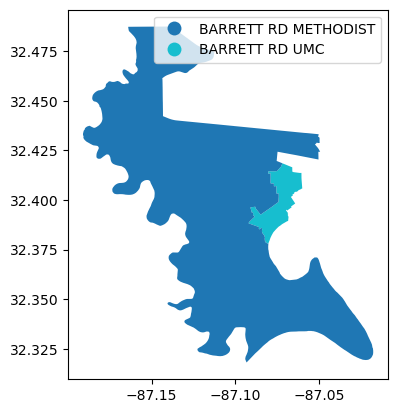

In [11]:
shapes_22[(shapes_22["County"]=="Dallas")&(shapes_22["Precinct"].str.contains("BARRETT"))].plot(column="Precinct",legend=True)

In [12]:
# # Note this switch was found by looking at other contests in the results
# shapes_22.loc[shapes_22["Precinct"]=="BARRETT RD METHODIST","UNIQUE_ID"] = "Dallas-:-BARRETT RD UMC"
# shapes_22.loc[shapes_22["Precinct"]=="BARRETT RD UMC","UNIQUE_ID"] = "Dallas-:-BARRETT RD METHODIST"

In [13]:
shapes_22[shapes_22["County"]=="Perry"].to_file("./perry_shps.shp")

In [14]:
shapes_22["Precinct"] = shapes_22["UNIQUE_ID"].apply(lambda x: x.split("-:-")[1])

In [15]:
results_24.loc[results_24["UNIQUE_ID"]=='Cullman-:-FAIRVIEW FIRE DEPT_ A-K','Precinct'] = 'FAIRVIEW FIRE DEPT TOWN HALL'
results_24.loc[results_24["UNIQUE_ID"]=='Cullman-:-FAIRVIEW TOWN HALL_ L-Z', 'Precinct'] = 'FAIRVIEW FIRE DEPT TOWN HALL'
results_24.loc[results_24["UNIQUE_ID"]=='Cullman-:-FAIRVIEW FIRE DEPT_ A-K','UNIQUE_ID'] = 'Cullman-:-FAIRVIEW FIRE DEPT TOWN HALL'
results_24.loc[results_24["UNIQUE_ID"]=='Cullman-:-FAIRVIEW TOWN HALL_ L-Z', 'UNIQUE_ID'] = 'Cullman-:-FAIRVIEW FIRE DEPT TOWN HALL'


In [16]:
results_24 = results_24.groupby(["UNIQUE_ID","COUNTYFP","County","Precinct"], as_index = False).sum()

In [17]:
# county_list = ['Baldwin', 'Barbour', 'Bullock', 'Butler', 'Choctaw', 'Clarke',
#        'Coffee', 'Conecuh', 'Covington', 'Crenshaw', 'Dale', 'Dallas',
#        'Escambia', 'Geneva', 'Greene', 'Hale', 'Henry', 'Houston',
#        'Jefferson', 'Lowndes', 'Macon', 'Marengo', 'Mobile', 'Monroe',
#        'Montgomery', 'Perry', 'Pickens', 'Pike', 'Russell', 'Sumter',
#        'Tuscaloosa', 'Washington', 'Wilcox']

In [18]:
county_list = set(results_24["County"])

In [19]:
# con_contests = [i for i in list(results_24.columns) if "GCON02" in i or "GCON07" in i or "GCON01" in i]
# results_24["CON_1_2_7_TOT"] = results_24[con_contests].sum(axis = 1)
# results_24[(results_24["CON_1_2_7_TOT"]==0)&(results_24["County"].isin(county_list))]["County"].unique()

# results_24 = results_24[(results_24["CON_1_2_7_TOT"]>0)]
# shapes_22 = shapes_22[shapes_22["County"].isin(county_list)]

In [20]:

county_new_shapes = ["Covington","Limestone","Calhoun","Butler", "Lee","Baldwin","Coffee","Henry","Houston","Bullock","Montgomery","Pike","Tuscaloosa","Mobile","Russell","Madison","Shelby","St. Clair","Jefferson","Morgan"]
county_dissolve = []
county_22_shapes = [i for i in county_list if i not in county_new_shapes and i not in county_dissolve]

In [21]:
county_22_shapes

['Lauderdale',
 'Perry',
 'Blount',
 'Clarke',
 'Conecuh',
 'Wilcox',
 'Lamar',
 'Winston',
 'Clay',
 'Randolph',
 'Etowah',
 'Marshall',
 'Geneva',
 'Barbour',
 'Walker',
 'Cullman',
 'Escambia',
 'Dale',
 'Cherokee',
 'Jackson',
 'Monroe',
 'Bibb',
 'Greene',
 'Tallapoosa',
 'Coosa',
 'Elmore',
 'Pickens',
 'DeKalb',
 'Fayette',
 'Dallas',
 'Lawrence',
 'Colbert',
 'Lowndes',
 'Choctaw',
 'Sumter',
 'Washington',
 'Hale',
 'Marion',
 'Franklin',
 'Crenshaw',
 'Chambers',
 'Autauga',
 'Cleburne',
 'Macon',
 'Marengo',
 'Chilton',
 'Talladega']

In [22]:
dissolve_shapes = shapes_22[shapes_22["County"].isin(county_dissolve)]
join_shapes = shapes_22[shapes_22["County"].isin(county_22_shapes)]

In [23]:
results_24_dissolve = results_24[results_24["County"].isin(county_dissolve)].copy(deep = True)
results_24_remaining = results_24[~results_24["County"].isin(county_dissolve)].copy(deep = True)

In [24]:
results_24_dissolve = results_24_dissolve.groupby(["COUNTYFP","County"], as_index = False).sum()

In [25]:
results_24_dissolve["Precinct"] = "Countywide"
results_24_dissolve["UNIQUE_ID"] = results_24_dissolve["County"] + "-:-" + results_24_dissolve["Precinct"]
results_24_dissolve = results_24_dissolve[list(results_24_remaining.columns)]

In [26]:
results_24 = pd.concat([results_24_remaining, results_24_dissolve])
results_24.reset_index(inplace = True, drop = True)

## Counties to Dissolve

In [27]:
dissolve_shapes = dissolve_shapes[["County","COUNTYFP","geometry"]]
dissolve_shapes = dissolve_shapes.dissolve(["County","COUNTYFP"])
dissolve_shapes.reset_index(inplace = True, drop = False)
dissolve_shapes["UNIQUE_ID"] = dissolve_shapes["County"]+"-:-Countywide"
dissolve_shapes["Precinct"] = "Countywide"
dissolve_shapes = dissolve_shapes[["UNIQUE_ID","COUNTYFP","County","Precinct","geometry"]]

In [28]:
dissolve_shapes

,UNIQUE_ID,COUNTYFP,County,Precinct,geometry


## Counties to use 2022

In [29]:
# Clean up the "Unassigned" precinct
join_shapes.loc[join_shapes["Precinct"]=="Unassigned","UNIQUE_ID"] = "Coffee-:-Fort Rucker"
join_shapes.loc[join_shapes["Precinct"]=="Unassigned","Precinct"] = "Fort Rucker"

In [30]:
join_shapes.loc[(join_shapes["County"]=="Crenshaw")&(join_shapes["Precinct"]=="PATSBURG DEPOT"),"UNIQUE_ID"] = "Crenshaw-:-PETREY COMM_ CTR"
join_shapes.loc[(join_shapes["County"]=="Crenshaw")&(join_shapes["Precinct"]=="LILLER'S STORE"),"UNIQUE_ID"] = "Crenshaw-:-SPRINGHILL FD"
join_shapes.loc[(join_shapes["County"]=="Crenshaw")&(join_shapes["Precinct"]=="BUSH'S GROCERY"),"UNIQUE_ID"] = "Crenshaw-:-SPRINGHILL FD"
join_shapes.loc[(join_shapes["County"]=="Crenshaw")&(join_shapes["Precinct"]=="VIDETTE COMM_ CTR"),"UNIQUE_ID"] = "Crenshaw-:-COUNTY COURTHOUSE"


In [31]:
join_shapes = join_shapes[["UNIQUE_ID","COUNTYFP","County","geometry"]]

In [32]:
updates = {"Washington-:-MALCOM CTR_":"Washington-:-MALCOLM CTR_",
"Washington-:-ST_ STEPHENS FIRE HOUSE":"Washington-:-ST_ STEPHENS NUTRITION CTR_",
"Conecuh-:-JOHNSONVILLE FIRE":"Conecuh-:-JOHNSVILLE FIRE",
"Butler-:-INDUSTRY OLD SCHOOL":"Butler-:-INDUSTRY OLD SCH HOUSE",
"Butler-:-FRIENDSHIP OLD SCHOOL":"Butler-:-FRIENDSHIP OLD SCH HOUSE",
"Butler-:-CHAPMAN VTG HOUSE":"Butler-:-CHAPMAN POST OFFICE",
'Geneva-:-PINEY GROVE':'Geneva-:-PINEY GROVE VTG HOUSE',
'Butler-:-HEALTH DEPT_':'Butler-:-LBW CONFERENCE CTR_',
'Butler-:-GEORGIANA NUTRITION CTR_':'Butler-:-SR_ MULTIPURPOSE CTR_',
'Marengo-:-RANGELINE BAPTISIT CH':'Marengo-:-RANGELINE BAPTIST CH',
# Calvary Baptist Church (Temporary location for Cottonwood Community Room)
'Houston-:-COTTONWOOD COMM_ RM':'Houston-:-CALVARY BAPTIST CHURCH',

# Note: Ending up swapping county
# 'Coffee-:-Unassigned', change name to Fort Rucker
# 'Coffee-:-ELBA NATIONAL GUARD':'Coffee-:-ELBA MASONIC LODGE',
# 'Coffee-:-COOL SPGS':'Coffee-:-TRI-COMM VFD (COOL SPGS)',
'Escambia-:-FIRST UN METHODIST':'Escambia-:-FIRST UNITED METHODIST',
'Escambia-:-OLD SCHOOL HOUSE':'Escambia-:-POARCH (OLD SCHL HOUSE)',
'Escambia-:-LITTLE ESCAMBIA V_H_':'Escambia-:-OSAKA CHURCH',
'Escambia-:-LITTLE ROCK STORE':'Escambia-:-LITTLE ROCK VFD',  
'Monroe-:-BUENA VISTA VRENDEN':'Monroe-:-BUENA VISTA VREN FD',
'Monroe-:-BURNT CORN FIRE DEPT':'Monroe-:-BETHANY BAPT (BURNT CORN)',
'Crenshaw-:-VFD HONORVILLE':'Crenshaw-:-VFD HONORAVILLE',
'Monroe-:-L PEACHTREE PACK BEND':'Monroe-:-LOWER PEACH TREE',
'Monroe-:-MEXIA FIRE STATION':'Monroe-:-LIGHTHOUSE BAPT CH',
'Monroe-:-MONROEVILLE FIRE ST':'Monroe-:-MONROEVILLE WATER TOWER',
'Monroe-:-OAK GROVE':'Monroe-:-OAK GROVE BAPT CH',
'Monroe-:-PETERMAN BAPTIST':'Monroe-:-PETERMAN BAPT CH',
'Monroe-:-WAINWRIGHT FINCHBURG':'Monroe-:-WAINWRIGHT FINCH FD',
'Monroe-:-ST JOHN AME CH':'Monroe-:-BEATRICE TOWN HALL',
#MONROE “St John AME Church was moved  to New Beatrice Town Hall”
'Clarke-:-WALKER SPRINGS':'Clarke-:-WALKER SPRNGS',
'Clarke-:-NETTLESBORO FIRE 112_1':'Clarke-:-NETTLESBORO',
'Clarke-:-MORNING STAR CHURCH':'Clarke-:-MORNING STAR',
'Clarke-:-OPINE TALLAHATTA  161_1':'Clarke-:-OPINE TALLAHATTA 161_1',
'Clarke-:-GOSPORT FIRE 61_1':'Clarke-:-GOSPORT FIRE',
'Clarke-:-JACKSON DOWNTOWN FIRE':'Clarke-:-JACKSON DOWNTOWN',
'Clarke-:-GROVE HILL CITY HALL':'Clarke-:-GROVE HILL TOWN HALL',    
"Clarke-:-JACKSON NAT'L GUARD":'Clarke-:-FIRST ASSEMBLY OF GOD',
'Russell-:-PITTSVIEW FIRE':'Russell-:-PITTSVIEW VFD',
'Russell-:-FIRE DEPT HURTSBORO':'Russell-:-HURTSBORO CITY VFD',
'Russell-:-COTTONTON FIRE STATION':'Russell-:-COTTONTON VFD',
'Russell-:-HATCHECHUBBEE FIRE':'Russell-:-HATCHECHUBBEE VFD',
'Dallas-:-EASTEND FIRE STA_':'Dallas-:-EASTEND FIRE STATION',
'Dallas-:-GOOD HOPE CH_ 00701_001': 'Dallas-:-GOOD HOPE 00701_001',
'Dallas-:-MT_ ZION CH_':  'Dallas-:-MT_ ZION CHURCH',
'Dallas-:-VALLEY GRANDE BAPT CH': 'Dallas-:-VALLEY GRANDE BAPTIST',
'Dallas-:-YMCA':'Dallas-:-WALKER JOHNSON YMCA',
'Dallas-:-NEW ST JOHNS BAPTIST CH':'Dallas-:-EBENZER MISS_ BAPTIST',
'Hale-:-MOUNDVILLE CITY HALL':'Hale-:-MOUNDVILLE COMMUNITY CTR',
'Hale-:-SAWYERVILLE HEAD START':'Hale-:-SAWYERVILLE VFD',
'Hale-:-MT_ HOREB BAPT_': 'Hale-:-OLD SUNSHINE SCHOOL',
'Wilcox-:-WILLIE B_ McCANTS PLACE':'Wilcox-:-WILLIE B_ MCCANTS PLACE',
'Wilcox-:-ST WISDOM BAPT': 'Wilcox-:-ST_ WISDOM BAPT CH',
'Wilcox-:-PINE APPLE FIRE STATION':'Wilcox-:-PINE APPLE LIBRARY',
'Wilcox-:-COY PUBLIC SCHOOL':'Wilcox-:-COY PUBLIC SCHOOL BLDG', 
'Dale-:-EWELL FIRE':'Dale-:-EWELL BIBLE BAPTIST',
'Dale-:-MIDLAND VOTING HALL':'Dale-:-MIDLAND CITY VOTING HALL',
"Greene-:-CHLOE'S RESTAURANT":'Greene-:-BAMA BINGO - SOUTH FORK',
'Greene-:-GREENE COUNTY COURTHOUSE':'Greene-:-WM MCKINLEY BRANCH C_ H',

'Greene-:-CLINTON COMM_ CTR_':'Greene-:-W_ GREENE FIRE STATION',
'Greene-:-MT_ HEBRON PRE-SCHOOL':'Greene-:-THE SPOT',
'Lowndes-:-LOWNDES CITY DEV OFC':'Lowndes-:-BURKVILLE FIRE STATION #2', # No documentation, but area overlaps
'Wilcox-:-PEACHTREE COMM_ CTR':'Wilcox-:-LOWER PEACHTREE COMM_ CTR',
'Wilcox-:-LAST CHANCE CH-':'Wilcox-:-PINE LEVEL AME CHURCH',
'Wilcox-:-FAITH FELLOWSHIP':'Wilcox-:-MT_ SINAI BAPTIST',
'Wilcox-:-SUNNY SOUTH BAPT':'Wilcox-:-FAITH WHOLE TRUTH CH',
'Wilcox-:-FURMAN TATES CHAPEL':'Wilcox-:-ZION REST BAPT CH',
'Wilcox-:-ST PAUL AME CH':'Wilcox-:-ZION REST BAPT CH',
'Blount-:-SNEAD COMM_ CTR_':'Blount-:-SNEAD',
'Cherokee-:-MT_ CALVARY BAPT_ CHURCH':'Cherokee-:-MT CALVARY BAPT_ CHURCH',
'Chilton-:-CANE CREEK GAP OF MT FS':'Chilton-:-CANE CREEK GAP OF MTN',
'Chilton-:-HILLCREST BAPTIST':'Chilton-:-HILLCREST BAPTIST CH',
'Chilton-:-MARS HILL-W CHILTON FS':'Chilton-:-MARS HILL/W CHILTON FS',
'Chilton-:-PROVIDENCE BAPTIST':'Chilton-:-PROVIDENCE BAPTIST CH',
    
'Chilton-:-UNION GROVE BAPTIST':'Chilton-:-UNION GROVE BAPTIST CH',
'Clay-:-COUNTY ANNEX':'Clay-:-COURTHOUSE ANNEX',
'Cleburne-:-CHULAFINNEE':'Cleburne-:-CHULAFINNEE BAPT CH',
'Cleburne-:-GREENS CHAPEL UMC':'Cleburne-:-GREENS CHAPEL UMC @ BEASON MIL',
'Cleburne-:-HOPEWELL SCHOOL':'Cleburne-:-OLD HOPEWELL CHURCH',
'Colbert-:-TUSCUMBIA CALVARY BAPT_':'Colbert-:-HELEN KELLER PUBLIC LIBRARY',
'Colbert-:-TREE HOUSE SCHOOL':'Colbert-:-TREE HOUSE SCH',
'Colbert-:-GRACE LIFE CH':'Colbert-:-GRACE LIFE',
'Colbert-:-SHEFFIELD REC_ CTR_':'Colbert-:-SHEFFIELD RECREATION',
'Coosa-:-GOODWATER COMM CTR':'Coosa-:-GOODWATER VFD',
    'Coosa-:-MARBLE VALLEY FD':'Coosa-:-MARBLE VALLEY VFD',
        'Coosa-:-RAY FD':'Coosa-:-RAY VFD',
 'Coosa-:-RICHVILLE FD':'Coosa-:-RICHVILLE VFD',
    'Coosa-:-ROCKFORD EVENT CENTER':'Coosa-:-ROCKFORD EVENT CTR',
'Cullman-:-BOLTE WHITE GROVE CH':'Cullman-:-BOLTE WHITE GROVE',
'Cullman-:-DONALD E_ GREEN SR STR':'Cullman-:-DONALD E_ GREEN SR CTR',
'Cullman-:-MOODY TOWN UNION HILL CH':'Cullman-:-MOODY TOWN UNION HILL',
'Cullman-:-WELTI MT_ ZION CH':'Cullman-:-WELTI MT_ ZION',
'Cullman-:-JOHNSON CROSSING VFD':'Cullman-:-WHITE CITY COMM CTR',
'St. Clair-:-ARGO TOWN HALL':'St. Clair-:-ARGO CITY HALL',
'St. Clair-:-BOYS&GIRLS CLUB-PELL CITY':'St. Clair-:-PELL CITY BOYS&GIRLS CLUB',
'St. Clair-:-RIVERSIDE TOWN HALL':'St. Clair-:-RIVERSIDE COMM CTR',
'Marshall-:-ALBERTVILLE 1ST BAPT':'Marshall-:-ALBERTVILLE 1ST BAPT CH',
'Marshall-:-BOAZ PARK & REC_ CTR':'Marshall-:-BOAZ PARK & REC',
'Marshall-:-UNION GROVE COMM_ CTR':  'Marshall-:-TOWN OF UNION GROVE',
'Marshall-:-C & C ASPHALT':'Marshall-:-MACK TRANSPORT',
'Marion-:-BYRD VFD VOTING CTR':'Marion-:-BYRD VOTING CTR',
'Marion-:-PEA RIDGE FIRE VOTING CTR':'Marion-:-PEARCES MILL PEA RIDGE',
'Lawrence-:-LOOSIER CH OF CHRIST16-1':'Lawrence-:-NEW LIBERTY GROVE 16-1',
'Lawrence-:-PINEY CROVE CH 32-1':'Lawrence-:-PINEY GROVE CH 32-1',
'Lauderdale-:-CLOVERDALE COMM_ CTR_':'Lauderdale-:-CLOVERDALE COMM_ CTR',
'Lauderdale-:-E_ CAMPUS WOODMONT BAPT_':'Lauderdale-:-E CAMPUS WOODMONT BAPT_',
'Lauderdale-:-FLORENCE- HIGH SCHOOL':'Lauderdale-:-FLORENCE- HIGH SCH',
'Lauderdale-:-ST_ FLORIAN SENIOR CTR_':'Lauderdale-:-ST_ FLORIAN SR CTR_',
'Lauderdale-:-UNDERWOOD COMM_ CTR_':'Lauderdale-:-UNDERWOOD COMM_ CTR',
'Fayette-:-COVIN BAPT CH':'Fayette-:-COVIN BAPT CHURCH',
'Fayette-:-ELM GROVE CH':'Fayette-:-ELM GROVE CHURCH',
'Fayette-:-FORDS-REHOBETH BAPT':'Fayette-:-FORDS-REHOBETH BAPT_',
'Fayette-:-LEE-PALESTINE CH':'Fayette-:-LEE-PALESTINE CHURCH',
'Fayette-:-RIDGE-CONCORD BAPT CH':'Fayette-:-RIDGE-CONCORD BAPT_',
'Fayette-:-STOUGH TRINITY CH':'Fayette-:-TRINITY CHURCH',
'Etowah-:-EAST GADSDEN REC_':'Etowah-:-EAST GADSDEN COMM_ CTR_',
'Etowah-:-LOOKOUT MTN_ COMM_': 'Etowah-:-LOOKOUT MT_ COMM_',
'Elmore-:-ASBURY KENT COMM_':'Elmore-:-ASBURY-KENT COMM_ CTR_',
'Elmore-:-FRIENDSHIP FIRE':'Elmore-:-FRIENDSHIP COMM_ CTR_',
'Elmore-:-KOWALIGA FIRE':'Elmore-:-KOWALIGA FIRE DEPT_',
'Elmore-:-REDHILL COMM_':'Elmore-:-REDHILL COMM_ CTR_',
'DeKalb-:-ADAMSBURG FIRE HALL':'DeKalb-:-ADAMSBURG FIRE DEPT',
'DeKalb-:-ARONEY FIRE': 'DeKalb-:-ARONEY FIRE DEPT',
'DeKalb-:-COPELAND BRIDGE LIBERTY':'DeKalb-:-COPELAND BRDG LIBERTY HILL',
'DeKalb-:-SAND MTN RSCH CTR':'DeKalb-:-CROSSVILLE SAND MTN RSCH',
'DeKalb-:-GERALDINE 1ST BAPTIST':'DeKalb-:-GERALDINE 1ST BAPT',
'DeKalb-:-HIGH POINT CH OF GOD':'DeKalb-:-HIGH POINT CHURCH OF GOD',
'DeKalb-:-MACEDONIA BAPTIST #2':'DeKalb-:-MACEDONIA BAPT #2',
'DeKalb-:-PAINTER-LIBERTY BAPTIST':'DeKalb-:-PAINTER-LIBERTY BAPT',
'DeKalb-:-PAYNE GAP CH':'DeKalb-:-PAYNE GAP CHURCH',
'DeKalb-:-PORTERSVILLE BAPTIST':'DeKalb-:-PORTERSVILLE BAPT',
'DeKalb-:-SHADY GROVE BAPTIST':'DeKalb-:-SHADY GROVE BAPT',
'DeKalb-:-TENBORECK COMM CTR':'DeKalb-:-TENBROECK COMM CTR',
'Tallapoosa-:-SARDIS COMM BUILDING':"Tallapoosa-:-CHURCH OF GOD'S GRACE",
'Etowah-:-DWIGHT BAPT_ CHURCH':'Etowah-:-ELLIOTT COMM_ CTR_',
'Talladega-:-STEMLEY VFD':'Talladega-:-STEMLEY VFD+',
'Talladega-:-BRECON REC CTR':'Talladega-:-CENTRAL AL COMM COLL',
'Talladega-:-LAY LAKE VFD':'Talladega-:-RUSSELL CHAPEL BAPT',
'Shelby-:-TURNER HOLLIS LEGION':'Shelby-:-BEULAH BAPTIST CHURCH',
'Shelby-:-ROY DOWNS MEMORIAL':'Shelby-:-CALERA BAPTIST CHURCH',
#'Shelby-:-DOUBLE OAK CH- CHELSEA' # Need to create this precinct
'Shelby-:-FAITH PRESBYTERIAN CH':'Shelby-:-HEARDMONT PARK SR_ COMM CTR',
'Shelby-:-RESTORE-1ST UN METHODIST':'Shelby-:-KINGWOOD CHURCH',
'Shelby-:-STEWART STUDENT RETREAT':'Shelby-:-MCCHESNEY STUDENT CTR_',

'Chambers-:-BUFFALO':'Chambers-:-BUFFALO/LEBANON PRES_',
'Chambers-:-SPARKLING SPRINGS': 'Chambers-:-MT_ SPRINGS',
'Chambers-:-LAKEVIEW': 'Chambers-:-LANIER',
'Elmore-:-WEOKA COMM_':'Elmore-:-WEOKA COMM_ CTR_',
'Elmore-:-WALLSBORO COMM_':'Elmore-:-WALLSBORO COMM_ CTR_',   
'Elmore-:-TITUS COMM_':'Elmore-:-TITUS COMM_ CTR_',
'Elmore-:-SEMAN COMM_':'Elmore-:-SEMAN CONG_ CHRISTIAN',
'Elmore-:-SANTUCK COMM_': 'Elmore-:-SANTUCK COMM_ CTR_',
'Elmore-:-NAZARENE':'Elmore-:-RIVER REGION CHURCH',
'Franklin-:-FRANKFORT MISSIONARY BAPT_':'Franklin-:-FRANKFORT MISSIONARY',
'Franklin-:-MT_ STAR HILLS SCHOOL':'Franklin-:-MT_ STAR STORE',
'Franklin-:-ROCKWOOD':'Franklin-:-DUNCAN FELLOWSHIP HALL',
'Limestone-:-ARDMORE SR_ CTR_':'Limestone-:-ARDMORE SENIOR CTR_',
'Limestone-:-ATHENS SR_ CITIZEN CTR_':'Limestone-:-ATHENS ACTIVITY CTR_',
'Limestone-:-FRIENDSHIP UMC':'Limestone-:-FRIENDSHIP CHURCH',
'Limestone-:-MAYS MEMORIAL BAPTIST':'Limestone-:-SARDIS SPRINGS BAPTIST',
'Limestone-:-LAMB OF GOD LUTHERAN CH':'Limestone-:-JAMES CLEMENS HIGH SCHOOL',
'Winston-:-WALDROP FREEWILL BAPT_':'Winston-:-NEEDMORE WALDROP CH',
'Winston-:-PEBBLE FIRE HOUSE':  'Winston-:-PEBBLE COMM_ CTR_',
'Winston-:-NESMITH COMM_ CTR_':'Winston-:-NESMITH CHURCH',
'Winston-:-NATURAL BRIDGE CITY HALL':'Winston-:-NATURAL BRIDGE COMM CENTER',
'Winston-:-HOUSTON FIRE DEPT_':'Winston-:-HOUSTON METHODIST CH',
'Winston-:-LYNN CITY HALL':'Winston-:-LYNN COMM CENTER',
'Randolph-:-CAVERS GROVE':'Randolph-:-FOSTERS CROSSROADS',
'Randolph-:-CORINTH':'Randolph-:-FOSTERS CROSSROADS',
'Randolph-:-SWAGG':'Randolph-:-FOSTERS CROSSROADS',
'Randolph-:-WESLEY CHAPEL':'Randolph-:-FOSTERS CROSSROADS',
'Walker-:-NAUVOO CITY HALL':'Walker-:-NAUVOO COMM CTR_',
'Walker-:-PARRISH CITY HALL': 'Walker-:-PARRISH TOWN HALL' ,
'Walker-:-THACH SCHOOL':'Walker-:-LAMON CHAPEL UMC',
'Walker-:-BETHEL ASSEMBLY OF GOD':'Walker-:-EDGIL GROVE BAPTIST CHURCH',
'Walker-:-COPELAND FERRY CH OF GOD':'Walker-:-PUMPKIN CENTER BAPT CH'
}

In [33]:
join_shapes["UNIQUE_ID"] = join_shapes["UNIQUE_ID"].map(updates).fillna(join_shapes["UNIQUE_ID"])

In [34]:
join_shapes[join_shapes["UNIQUE_ID"].str.contains("4015")]

,UNIQUE_ID,COUNTYFP,County,geometry


In [35]:
join_shapes = join_shapes.dissolve(["UNIQUE_ID","COUNTYFP","County"], as_index = False)

In [36]:
join_shapes[join_shapes["UNIQUE_ID"].str.contains("4015")]

,UNIQUE_ID,COUNTYFP,County,geometry


In [37]:
join_shapes["Precinct"] = join_shapes["UNIQUE_ID"].apply(lambda x: x.split("-:-")[1])

In [38]:
join_shapes[join_shapes["UNIQUE_ID"].str.contains("4015")]

,UNIQUE_ID,COUNTYFP,County,geometry,Precinct


In [39]:
results_carry = results_24[results_24["County"].isin(county_22_shapes)]

In [40]:
m = pd.merge(join_shapes, results_carry, how = "outer", on = "UNIQUE_ID", indicator = True)

In [41]:
m["_merge"].value_counts()

_merge
both          1075
left_only        0
right_only       0
Name: count, dtype: int64

In [42]:
list(m[m["_merge"]=="left_only"].sort_values("UNIQUE_ID")["UNIQUE_ID"])

[]

In [43]:
list(m[m["_merge"]=="right_only"].sort_values("UNIQUE_ID")["UNIQUE_ID"])

[]

In [44]:
results_24[(results_24["County"]=="Jefferson")&(results_24["UNIQUE_ID"].str.contains("22"))]

,UNIQUE_ID,COUNTYFP,County,Precinct,G24A01NO,G24A01YES,G24AJ1OWRI,G24AJ1RMCC,G24AJ2OWRI,G24AJ2RBRY,...,GCON04OWRI,GCON04RADE,GCON05OWRI,GCON05RSTR,GCON06DAND,GCON06OWRI,GCON06RPAL,GCON07DSEW,GCON07OWRI,GCON07RLIT
903,Jefferson-:-PREC 1220 - WILLOW WOOD RECREA,73,Jefferson,PREC 1220 - WILLOW WOOD RECREA,179,394,24,101,26,98,...,0,0,0,0,0,0,0,701,1,40
941,Jefferson-:-PREC 2200 - CENTRAL PARK ELEME,73,Jefferson,PREC 2200 - CENTRAL PARK ELEME,172,397,11,90,11,88,...,0,0,0,0,0,0,0,765,0,26
942,Jefferson-:-PREC 2210 - JONESBORO ELEMENTA,73,Jefferson,PREC 2210 - JONESBORO ELEMENTA,105,255,19,125,14,128,...,0,0,0,0,0,0,0,523,2,95
943,Jefferson-:-PREC 2215 - GRANT STREET BAPTI,73,Jefferson,PREC 2215 - GRANT STREET BAPTI,209,523,31,566,33,559,...,0,0,0,0,0,0,0,714,0,463
944,Jefferson-:-PREC 2220 - GLEN IRIS ELEMENTA,73,Jefferson,PREC 2220 - GLEN IRIS ELEMENTA,227,717,104,440,95,436,...,0,0,0,0,0,0,0,981,2,261
945,Jefferson-:-PREC 2240 - FIRE DEPARTMENT AD,73,Jefferson,PREC 2240 - FIRE DEPARTMENT AD,92,334,16,88,16,87,...,0,0,0,0,0,0,0,713,0,35
946,Jefferson-:-PREC 2245/3060 - BESSEMER CIVI,73,Jefferson,PREC 2245/3060 - BESSEMER CIVI,738,1751,123,1042,124,1020,...,0,0,0,0,0,0,0,3028,2,732
947,Jefferson-:-PREC 2250 - MORE THAN CONQUERO,73,Jefferson,PREC 2250 - MORE THAN CONQUERO,164,409,26,81,27,71,...,0,0,0,0,0,0,0,830,2,20
948,Jefferson-:-PREC 2260 - WILKERSON MIDDLE S,73,Jefferson,PREC 2260 - WILKERSON MIDDLE S,163,385,18,52,18,51,...,0,0,0,0,0,0,0,691,1,17
949,Jefferson-:-PREC 2270 - MOUNT ZION MISSION,73,Jefferson,PREC 2270 - MOUNT ZION MISSION,257,212,10,65,11,62,...,0,0,0,0,0,0,0,714,0,19


## Counties with new shapes

In [45]:
shelby = gp.read_file("./raw-from-source/Alabama/Shelby/shelby_precs_24_clean.geojson")
shelby = shelby[["UNIQUE_ID","geometry"]].copy(deep = True)

In [46]:
st_clair = gp.read_file("./raw-from-source/Alabama/St. Clair/st_clair_precs_join_ready.geojson")

In [47]:
st_clair["UNIQUE_ID"] = "St. Clair-:-"+st_clair['Precinct']
st_clair=st_clair[["UNIQUE_ID","geometry"]].copy(deep = True)

In [48]:
madison = gp.read_file("./raw-from-source/Alabama/Madison/madison_precs_join_ready.geojson")
madison["UNIQUE_ID"] = "Madison-:-"+madison["Precinct"]
madison = madison[["UNIQUE_ID","geometry"]].copy(deep = True)

<Axes: >

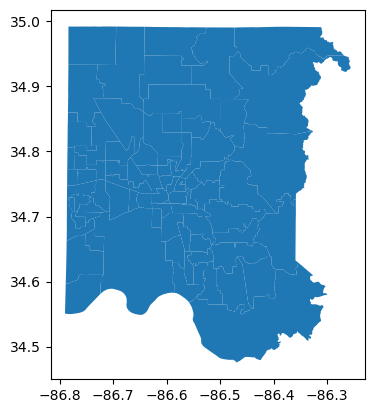

In [49]:
madison.plot()

In [50]:
baldwin = gp.read_file("./raw-from-source/Alabama/Baldwin/baldwin_precs_joined.geojson/baldwin_precs_joined.shp")
henry = gp.read_file("./raw-from-source/Alabama/Henry/henry_2024/henry_2024.shp")
houston = gp.read_file("./raw-from-source/Alabama/Houston/houston_precs.geojson")
bullock = gp.read_file("./raw-from-source/Alabama/Bullock/BULLOCK_2024.geojson")
montgomery = gp.read_file("./raw-from-source/Alabama/Montgomery/precs.geojson")
#pike = gp.read_file("./raw-from-source/Alabama/Pike/pike_24/pike_24.shp")
pike = gp.read_file("./raw-from-source/Alabama/Pike/fwdvotingprecinctsshapefile/PikeCountyALPrecinctsRDOct23.shp")
tuscaloosa = gp.read_file("./raw-from-source/Alabama/Tuscaloosa/tuscaloosa_precs.geojson")
mobile = gp.read_file("./raw-from-source/Alabama/Mobile/mobile_precs24.json")
russell = gp.read_file("./raw-from-source/Alabama/Russell/russell_geocoded/russell_geocoded.shp")
jefferson = gp.read_file("./raw-from-source/Alabama/Jefferson/jefferson_24/jefferson_24.shp")
morgan = gp.read_file("./raw-from-source/Alabama/Morgan/morgan_precs_cleaned/morgan_precs_cleaned.shp")
coffee = gp.read_file("./raw-from-source/Alabama/Coffee/coffee_24_updates/coffee_24_updates.shp")
lee = gp.read_file("./raw-from-source/Alabama/Lee/lee_final_edits.geojson")
butler = gp.read_file("./raw-from-source/Alabama/Butler/butler_precs_aligned.geojson")
limestone = gp.read_file("./raw-from-source/Alabama/Limestone/limestone_precs.geojson")
covington = gp.read_file("./raw-from-source/Alabama/Covington/precs_map.geojson")

In [51]:
russell_new = gp.read_file("./raw-from-source/Alabama/Russell/Russell_Precincts_SHP/AL57_Precincts.shp")

In [52]:
unique_id = [ 'Russell-:-MARTIN IDLE COMM CTR',
 'Russell-:-LADONIA VFD',
 'Russell-:-CENTRAL ACTIVITES BLDG',
 'Russell-:-GOLDEN ACRES BAPT',
 'Russell-:-RUSSELL COUNTY C_H_',
 'Russell-:-PHENIX CITY YOUTH CTR',
 'Russell-:-SPENCER REC CTR',
 'Russell-:-MT OLIVE SUNDERLAND VFD',
 'Russell-:-FT_ MITCHELL COMM CTR',
 'Russell-:-CVCC',
 'Russell-:-CRAWFORD COMM CTR',
 'Russell-:-DIXIE VFD',            
 'Russell-:-COTTONTON VFD',
 'Russell-:-PITTSVIEW VFD',
 'Russell-:-OLD COUNTY C_H_',
 'Russell-:-HATCHECHUBBEE VFD',
 'Russell-:-HURTSBORO CITY VFD',
 'Russell-:-AUSTIN SUMBRY PARK']

In [53]:
prec_nums = ['00101',
 '00201',
 '00301',
 '00302',
 '00401',
 '00402',
 '00403',
 '00501',
 '00502',
 '00601',
 '00602',
 '00603',
 '00701',
 '00702',
 '00703',
 '00704',
 '00705',
 '00706']

In [54]:
russell_dict = dict(zip(prec_nums,unique_id))

In [55]:
russell_dict

{'00101': 'Russell-:-MARTIN IDLE COMM CTR',
 '00201': 'Russell-:-LADONIA VFD',
 '00301': 'Russell-:-CENTRAL ACTIVITES BLDG',
 '00302': 'Russell-:-GOLDEN ACRES BAPT',
 '00401': 'Russell-:-RUSSELL COUNTY C_H_',
 '00402': 'Russell-:-PHENIX CITY YOUTH CTR',
 '00403': 'Russell-:-SPENCER REC CTR',
 '00501': 'Russell-:-MT OLIVE SUNDERLAND VFD',
 '00502': 'Russell-:-FT_ MITCHELL COMM CTR',
 '00601': 'Russell-:-CVCC',
 '00602': 'Russell-:-CRAWFORD COMM CTR',
 '00603': 'Russell-:-DIXIE VFD',
 '00701': 'Russell-:-COTTONTON VFD',
 '00702': 'Russell-:-PITTSVIEW VFD',
 '00703': 'Russell-:-OLD COUNTY C_H_',
 '00704': 'Russell-:-HATCHECHUBBEE VFD',
 '00705': 'Russell-:-HURTSBORO CITY VFD',
 '00706': 'Russell-:-AUSTIN SUMBRY PARK'}

In [56]:
russell_new["County"] = "Russell"
russell_new["COUNTYFP"] = "113"
russell_new["UNIQUE_ID"] = russell_new["Precinct"].map(russell_dict)

In [57]:
russell_new["Precinct"] = russell_new["UNIQUE_ID"].map(lambda x:x.split("-:-")[1])

In [58]:
russell_new = russell_new.to_crs(russell.crs)
russell_new = russell_new[['UNIQUE_ID', 'COUNTYFP', 'County', 'Precinct', 'geometry']]

In [59]:
russell = russell_new.copy(deep = True)

In [60]:
calhoun = gp.read_file("./raw-from-source/Alabama/Calhoun/calhoun_edits.geojson")

In [61]:
jefferson_updates = {'Jefferson-:-PREC 1080 - MILES COLLEGE GYM':'Jefferson-:-PREC 1080 - FRENCH STUDENT CEN',
'Jefferson-:-PREC 1230 - NEW RISING STAR MI':'Jefferson-:-PREC 1230 - GREATER EMMANUEL T',
'Jefferson-:-PREC 2120 - DUNBAR-ABRAMS COMM':'Jefferson-:-PREC 2120 - MACEDONIA BAPTIST',
'Jefferson-:-PREC 2090 - HOLY FAMILY CRISTO':'Jefferson-:-PREC 2090 - SIXTH AVENUE BAPTI',
'Jefferson-:-PREC 2420 - BELL PHYSICAL EDUC':'Jefferson-:-PREC 2100/2420 - MEMORIAL PARK',
'Jefferson-:-PREC 2100 - MEMORIAL RECREATIO':'Jefferson-:-PREC 2100/2420 - MEMORIAL PARK',          
'Jefferson-:-PREC 2365/3160 - ROSS BRIDGE W':'Jefferson-:-PREC 2365/3160 - CHURCH AT ROS',
'Jefferson-:-PREC 3020 - OASIS OF PRAISE CH':'Jefferson-:-PREC 3020 - GRACE LIFE BAPTIST',
'Jefferson-:-PREC 3220 - OAK GROVE FIRST BA':'Jefferson-:-PREC 3220 - EZRA BAPTIST CHURC',
'Jefferson-:-PREC 4015 - GARDENDALE MT_ VER':'Jefferson-:-PREC 4015 - HOPE COMMUNITY CHU',
'Jefferson-:-PREC 4170 - KIMBERLY UNITED ME':'Jefferson-:-PREC 4170 - NORTH POINT COMMUN',
'Jefferson-:-PREC 4190 - THE CHURCH AT GRAN':'Jefferson-:-PREC 4190 - IRONDALE CIVIC CEN',
'Jefferson-:-PREC 5020 - VESTAVIA HILLS UNI':'Jefferson-:-PREC 5020 - VESTAVIA HILLS MET',
'Jefferson-:-PREC 5220 - VESTAVIA CITY HALL':'Jefferson-:-PREC 5220 - VESTAVIA CIVIC CEN',
'Jefferson-:-PREC 2230 - AVONDALE ELEMENTAR':'Jefferson-:-PREC 2180 - AVONDALE PUBLIC LI',}

In [62]:
jefferson["UNIQUE_ID"] = jefferson["UNIQUE_ID"].map(jefferson_updates).fillna(jefferson["UNIQUE_ID"])

In [63]:
jefferson = jefferson.dissolve("UNIQUE_ID", as_index = False)

In [64]:
jefferson = jefferson[["UNIQUE_ID","geometry"]].copy(deep = True)

### Initial Cleaning

In [65]:
mobile_mapping = {'VD07':'Mobile-:-1ST BAPTIST CH OF WILMER',
'VD10':'Mobile-:-1ST BAPTIST CH SATSUMA',
'VD76':'Mobile-:-1ST EVANGELICAL METHODIST',
'VD48':'Mobile-:-ABBA SHRINE TEMPLE',
'VD19':'Mobile-:-AZALEA CITY CH OF CHRIST',
'VD47':'Mobile-:-BAKER HIGH SCH',
'VD78':'Mobile-:-BAYOU LA BATRE COMM_ CTR',
'VD69':'Mobile-:-BC RAIN HIGH SCHOOL',
'VD03':'Mobile-:-BETHEL BAPTIST CH',
'VD40':'Mobile-:-BISHOP STATE',
'VD12':'Mobile-:-BLOUNT HIGH SCH',
'VD33':'Mobile-:-BOYS & GIRLS CLUB OF MOBILE',
'VD62':'Mobile-:-BURNS MIDDLE SCHOOL',
'VD72':'Mobile-:-BURROUGHS ELEM_',
'VD80':'Mobile-:-CHURCH OF THE ISLAND',
'VD55':'Mobile-:-CLEARWATER CHRISTIAN CH',
'VD41':'Mobile-:-COLLIER ELEM',
'VD14':'Mobile-:-COLLINS RHODES ELEM',
'VD64':'Mobile-:-COVENANT ACADEMY, INC',
'VD52':'Mobile-:-CRAIGHEAD ELEM',
'VD57':'Mobile-:-CREEKWOOD CH OF CHRIST',
'VD06':'Mobile-:-CREOLA SENIOR CTR',
'VD68':'Mobile-:-CYPRESS SHORES BAPTIST',
'VD50':'Mobile-:-DAVIDSON HIGH SCH',
'VD09':'Mobile-:-DESTINATION CHURCH',
'VD63':'Mobile-:-DODGE ELEM_',
'VD53':'Mobile-:-EICHOLD MERTZ ELEM',
'VD45':'Mobile-:-E_ R_ DICKSON ELEM',
'VD25':'Mobile-:-FOREST HILL ELEM',
'VD21':'Mobile-:-FREEDOM HOUSE OF REVIVAL',
'VD34':'Mobile-:-FRIENDSHIP  MISSIONARY',
'VD77':'Mobile-:-FRIENDSHIP BAPTIST CH',
'VD74':'Mobile-:-GRAND BAY MIDDLE SCH',
'VD71':'Mobile-:-HOLLINGERS ISLAND ELEM',
'VD30':'Mobile-:-HOLLOWAY ELEM',
'VD22':'Mobile-:-HOLY NAME OF JESUS CH',
'VD20':'Mobile-:-HOPE CHAPEL A_M_E_Z_',
'VD24':'Mobile-:-INDEPENDENT LIVING CTR',
'VD43':'Mobile-:-JAMES SEALS JR_ PARK & REC',
'VD27':'Mobile-:-JOSEPH DOTCH COMM CTR',
'VD17':'Mobile-:-J_C_ DAVIS AUDITORIUM',
'VD08':'Mobile-:-J_E_ TURNER ELEM_',
'VD59':'Mobile-:-KATE SHEPARD ELEM',
'VD51':'Mobile-:-LEINKAUF ELEM',
'VD70':'Mobile-:-MAGNOLIA SPRINGS BAPTIST',
'VD66':'Mobile-:-MEADOWLAKE ELEM_',
'VD01':'Mobile-:-MEMORIAL BAPTIST CH',
'VD31':'Mobile-:-MICHAEL FIGURES COMM CTR',
'VD39':'Mobile-:-MOBILE COMM_ ACTION',
'VD36':'Mobile-:-MOBILE MUSEUM OF ART',
'VD04':'Mobile-:-McDAVID JONES ELEM',
'VD58':'Mobile-:-OUR SAVIOR CATHOLIC CH',
'VD61':'Mobile-:-PALMER PILLANS MIDDLE',
'VD38':'Mobile-:-PHILLIPS PREPARATORY SCH',
'VD02':'Mobile-:-PINE GROVE MISSIONARY BAPT CH',
'VD49':'Mobile-:-REGENCY CH OF CHRIST',
'VD54':'Mobile-:-REVELATION MISSIONARY',
'VD44':'Mobile-:-RISE CHURCH',
'VD26':'Mobile-:-ROBBINS ELEM',
'VD29':'Mobile-:-ROBERT L_ HOPE COMM CTR',
'VD15':'Mobile-:-SARALAND CIVIC CTR',
'VD16':'Mobile-:-SEMMES COMM CTR',
'VD18':'Mobile-:-SEMMES FIRST BAPTIST',
'VD13':'Mobile-:-SHELTON BEACH RD BAPT',
'VD75':'Mobile-:-ST_ ELMO ELEM_',
'VD35':'Mobile-:-ST_ JOHN UMC',
'VD79':'Mobile-:-ST_ MICHAEL CATHOLIC CH',
'VD37':'Mobile-:-ST_ PAULS EPISCOPAL CH',
'VD73':'Mobile-:-ST_ PHILIP NERI CATHOLIC',
'VD28':'Mobile-:-SUNLIGHT AUDITORIUM',
'VD56':'Mobile-:-SURGE CHURCH',
'VD60':'Mobile-:-THE GRAND HALL',
'VD11':'Mobile-:-THE RIVER',
'VD32':'Mobile-:-THOMAS SULLIVAN COMM CTR',
'VD46':'Mobile-:-THREE CIRCLE CH MIDTOWN',
'VD67':'Mobile-:-TILLMANS CORNER COMM_ CTR',
'VD05':'Mobile-:-TURNERVILLE BAPTIST CH',
'VD65':'Mobile-:-UNION BAPTIST CHURCH',
'VD42':'Mobile-:-VIA_ SENIOR CTR',
'VD23':'Mobile-:-VIGOR HIGH SCH'}

In [66]:
pike_mapping = {'1':'Pike-:-TROY PUBLIC LIBRARY',
'2':'Pike-:-MEEKSVILLE STORM SHELTER',
'3':'Pike-:-CHINA GROVE CO_ BLDG_',
'4':'Pike-:-HAMILTON CROSS ROADS',
'5':'Pike-:-NEEDMORE VOTING CTR #1',
'6':'Pike-:-COLLEGEDALE CH OF CHRIST',
'7':'Pike-:-SACO VFD #1',
'8':'Pike-:-EBENEZER VOTING CTR #1',
'9':'Pike-:-JOSIE CO BLDG',
'10':'Pike-:-ENON CO BLDG',
'11':'Pike-:-SWEET PILGRIM CH',
'12':'Pike-:-BANKS VOTING CTR #1',
'13':'Pike-:-TROY REC CTR',
'14':'Pike-:-BRUNDIDGE STATION',
'15':'Pike-:-TENNILLE METHODIST CH',
'16':'Pike-:-TARENTUM COMM CLUBHOUSE',
'17':'Pike-:-SPRINGHILL VFD',
'18':'Pike-:-HEPHZIBAH VOTING CTR #1',
'19':'Pike-:-GALLOWAY RD COMM CTR',
'20':'Pike-:-SPRINGHILL HOUSING',
'21':'Pike-:-PIKE CO COURTHOUSE',
'22':'Pike-:-FIRST BAPT CHURCH',
'23':'Pike-:-HENDERSON VOTING CTR #1',
'24':'Pike-:-GOSHEN TOWN HALL',
'25':'Pike-:-RURAL HOME CO BLDG',
'26':'Pike-:-ANTIOCH CH OF CHRIST',
'27':'Pike-:-OAK BOWERY CH OF CHRIST',
'28':'Pike-:-NEEDMORE VOTING CTR #2',
'30':'Pike-:-BANKS VOTING CTR #2',
'31':'Pike-:-GOLDEN SATELLITE BLDG',
'32':'Pike-:-EBENEZER VOTING CTR #2',
'33':'Pike-:-HENDERSON VOTING CTR #2',
'34':'Pike-:-SACO VFD #2',
'35':'Pike-:-HEPHZIBAH VOTING CTR #2'}

In [67]:
calhoun_mapping = {'Calhoun-:-ANNISTON THANKFUL BAPT_':'Calhoun-:-ANNISTON THANKFUL BAPT',
'Calhoun-:-ASBERRY BAPT_':'Calhoun-:-ASBERRY BAPT',
'Calhoun-:-A_P_ HOLLINGSWORTH COMM_':'Calhoun-:-A_P_ HOLLINGSWORTH COMM',
'Calhoun-:-BOILING SPRINGS BAPT_':'Calhoun-:-BOILING SPRINGS BAPT',
'Calhoun-:-FRIENDSHIP COMM_ CTR': 'Calhoun-:-FRIENDSHIP COMM CTR',
'Calhoun-:-HARVEST CHURCH OF GOD':'Calhoun-:-HARVEST CH OF GOD',
'Calhoun-:-JACKSONVILLE WESTSIDE BAPT_':'Calhoun-:-JACKSONVILLE WESTSIDE BAPT',
'Calhoun-:-MT_ VIEW BAPT_': 'Calhoun-:-MT_ VIEW BAPT',
'Calhoun-:-OAK GROVE BAPT_':'Calhoun-:-OAK GROVE BAPT',
'Calhoun-:-OHATCHEE 1ST BAPT_':'Calhoun-:-OHATCHEE 1ST BAPT',
'Calhoun-:-TRINITY MISSIONARY BAPT_':'Calhoun-:-TRINITY MISSIONARY BAPT',
'Calhoun-:-WEST PARK HEIGHTS BAPT_': 'Calhoun-:-W PARK HEIGHTS BAPT',
'Calhoun-:-WHITE PLAINS 1ST BAPT_':'Calhoun-:-WHITE PLAINS 1ST BAPT',
'Calhoun-:-WIGGINS COMM_ CTR':'Calhoun-:-WIGGINS COMM CTR',
'Calhoun-:-1ST UN_ METHODIST-WEAVER':'Calhoun-:-WEAVER MEETING CTR',
'Calhoun-:-JACKSONVILLE 1ST BAPT_':'Calhoun-:-ROWE HALL',
'Calhoun-:-CALHOUN CO_ HWY DEPT_':'Calhoun-:-TREDEGAR CHAPEL CH',
'Calhoun-:-FRIENDSHIP BAPT_':'Calhoun-:-TREDEGAR CHAPEL CH',}

In [68]:
calhoun["UNIQUE_ID"] = calhoun["UNIQUE_ID"].map(calhoun_mapping).fillna(calhoun["UNIQUE_ID"])

In [69]:
set(results_24[results_24["County"]=="Calhoun"]["UNIQUE_ID"]).symmetric_difference(set(calhoun["UNIQUE_ID"]))

set()

In [70]:
pike["Precinct_2"] = pike["Precinct_2"].astype(str)
pike["UNIQUE_ID"] = pike["Precinct_2"].map(pike_mapping)

In [71]:
baldwin["UNIQUE_ID"] = "Baldwin-:-"+baldwin["Name"]
baldwin = baldwin[["UNIQUE_ID","geometry"]].copy(deep = True)

henry = henry[["UNIQUE_ID","geometry"]].copy(deep = True)

houston["NAME"] = "Houston-:-"+houston["NAME"]
houston.rename(columns = {"NAME":"UNIQUE_ID"}, inplace = True)

bullock = bullock[["UNIQUE_ID","geometry"]].copy(deep = True)

montgomery["DISTRICT"] = "Montgomery-:-"+montgomery["DISTRICT"]
montgomery.rename(columns = {"DISTRICT":"UNIQUE_ID"}, inplace = True)

pike = pike[["UNIQUE_ID","geometry"]].copy(deep = True)

tuscaloosa["LOCATION"] = "Tuscaloosa"+"-:-"+tuscaloosa["LOCATION"]
tuscaloosa.rename(columns = {"LOCATION":"UNIQUE_ID"}, inplace = True)
tuscaloosa = tuscaloosa[["UNIQUE_ID","geometry"]].copy(deep = True)

mobile["UNIQUE_ID"] = mobile["VD2024"].map(mobile_mapping).fillna(mobile["VD2024"])
mobile = mobile[["UNIQUE_ID","geometry"]].copy(deep = True)

russell = russell[["UNIQUE_ID","geometry"]].copy(deep = True)

morgan = morgan[["UNIQUE_ID","geometry"]].copy(deep = True)

coffee = coffee[["UNIQUE_ID","geometry"]].copy(deep = True)

lee["UNIQUE_ID"] = "Lee-:-"+lee["UNIQUE_ID"]
lee = lee[["UNIQUE_ID", "geometry"]].copy(deep = True)

butler = butler[["UNIQUE_ID","geometry"]].copy(deep = True)
calhoun = calhoun[["UNIQUE_ID","geometry"]].copy(deep = True)
limestone = limestone[["UNIQUE_ID","geometry"]].copy(deep = True)

covington = covington[["UNIQUE_ID","geometry"]].copy(deep = True)

In [72]:
set(lee["UNIQUE_ID"]).symmetric_difference(set(results_24[results_24["County"]=="Lee"]["UNIQUE_ID"]))

set()

In [73]:
baldwin = baldwin.to_crs(shapes_22.crs)
henry = henry.to_crs(shapes_22.crs)
houston = houston.to_crs(shapes_22.crs)

bullock = bullock.to_crs(shapes_22.crs)
montgomery = montgomery.to_crs(shapes_22.crs)
pike = pike.to_crs(shapes_22.crs)

tuscaloosa = tuscaloosa.to_crs(shapes_22.crs)
mobile = mobile.to_crs(shapes_22.crs)

russell = russell.to_crs(shapes_22.crs)

st_clair = st_clair.to_crs(shapes_22.crs)
shelby = shelby.to_crs(shapes_22.crs)
madison = madison.to_crs(shapes_22.crs)
jefferson = jefferson.to_crs(shapes_22.crs)
morgan = morgan.to_crs(shapes_22.crs)
coffee = coffee.to_crs(shapes_22.crs)
lee = lee.to_crs(shapes_22.crs)
butler = butler.to_crs(shapes_22.crs)
calhoun = calhoun.to_crs(shapes_22.crs)
limestone = limestone.to_crs(shapes_22.crs)
covington = covington.to_crs(shapes_22.crs)

In [74]:
calhoun = calhoun.dissolve("UNIQUE_ID", as_index = False)

In [75]:
new_shapes = gp.GeoDataFrame(pd.concat([covington,limestone, calhoun, butler, lee, coffee, baldwin,henry,houston,bullock,montgomery,pike,tuscaloosa,mobile,russell,st_clair,shelby,madison,jefferson,morgan]))

In [76]:
new_shapes["UNIQUE_ID"].value_counts()

UNIQUE_ID
Covington-:-EVANS MEMORIAL CIVIC CTR    1
Madison-:-JACKSON WAY BAPT CH           1
Shelby-:-SOUTH SHELBY BAPT_ CH          1
Shelby-:-MCCHESNEY STUDENT CTR_         1
Shelby-:-VALLEYDALE BAPTIST             1
                                       ..
Montgomery-:-302                        1
Montgomery-:-303                        1
Montgomery-:-304                        1
Montgomery-:-305                        1
Morgan-:-LEBANON BAPT CH                1
Name: count, Length: 872, dtype: int64

In [77]:
new_results = results_24[results_24["County"].isin(county_new_shapes)]

In [78]:
id_update_dict = pd.read_csv("./raw-from-source/new_shps_join.csv")

In [79]:
id_update_dict = dict(zip(id_update_dict["shp_id"], id_update_dict["elec_id"]))

In [80]:
id_update_dict

{'Baldwin-:-Barnwell Volunteer Fire Department': 'Baldwin-:-BARNWELL VFD',
 'Baldwin-:-Bay Minette City Hall and Civic Center': 'Baldwin-:-BAY MINETTE CITY HALL/CIVIC',
 'Baldwin-:-Belforest Christian Church': 'Baldwin-:-BELFOREST CHRISTIAN CH',
 'Baldwin-:-Fishermen Baptist Church': 'Baldwin-:-BON SECOUR FISHERMAN BAPT',
 'Baldwin-:-East Pointe Baptist Church': 'Baldwin-:-BROMLEY EAST POINTE BAPT',
 'Baldwin-:-Church of His Presence': 'Baldwin-:-CH OF HIS PRESENCE',
 'Baldwin-:-Clear Springs United Methodist Church Fellowship Hall': 'Baldwin-:-CLR SPRNGS FELLOWSHIP',
 'Baldwin-:-Crossroads Volunteer Fire Department': 'Baldwin-:-CROSSROADS VFD',
 'Baldwin-:-Daphne Civic Center': 'Baldwin-:-DAPHNE CIVIC CTR',
 'Baldwin-:-Douglasville Boykin Center': 'Baldwin-:-DOUGLASVILLE BOYKIN',
 'Baldwin-:-Eastern Shore Baptist Church': 'Baldwin-:-EASTERN SHORE BAPT',
 'Baldwin-:-Elberta Civic Center': 'Baldwin-:-ELBERTA CIVIC CTR',
 'Baldwin-:-Ellisville Community Center': 'Baldwin-:-ELLISVILLE COM

In [81]:
henry_updates = {"Henry-:-EDWIN VTG CTR_":"Henry-:-EDWIN CLUBHOUSE",
"Henry-:-LAWRENCEVILLE VT_ HOUSE":"Henry-:-SARDIS NORTH",
"Henry-:-HERNDON-WARD GYM":"Henry-:-ABBEVILLE FIRST BAPTIST", 
"Henry-:-UNION VT_ HOUSE":"Henry-:-UNION FREEWILL BAPTIST",
"Henry-:-DOUGLAS CROSSROADS":"Henry-:-SARDIS SOUTH",
"Henry-:-HEADLAND VTG CTR_ 1":"Henry-:-HEADLAND METHODIST CH"}

In [82]:
henry["UNIQUE_ID"]

0        Henry-:-GREATER SHILOH BAPT_
1     Henry-:-LAWRENCEVILLE VT_ HOUSE
2              Henry-:-JUDSON BAPTIST
3         Henry-:-HEADLAND VTG CTR_ 1
4              Henry-:-BALKUM BAPTIST
5          Henry-:-DOUGLAS CROSSROADS
6              Henry-:-EDWIN VTG CTR_
7          Henry-:-HALEBURG CITY HALL
8            Henry-:-HERNDON-WARD GYM
9         Henry-:-JACKSON'S CHAPEL CH
10         Henry-:-NEWVILLE VT_ HOUSE
11           Henry-:-OLD ZION BAPTIST
12       Henry-:-SHORTERVILLE BAPTIST
13            Henry-:-UNION VT_ HOUSE
Name: UNIQUE_ID, dtype: object

<Axes: >

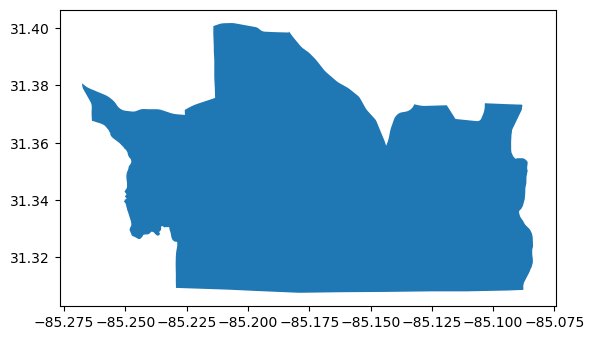

In [83]:
henry[henry["UNIQUE_ID"]=="Henry-:-DOUGLAS CROSSROADS"].plot()

In [84]:
new_shapes["UNIQUE_ID"] = new_shapes["UNIQUE_ID"].map(id_update_dict).fillna(new_shapes["UNIQUE_ID"])

In [85]:
new_shapes["UNIQUE_ID"] = new_shapes["UNIQUE_ID"].map(henry_updates).fillna(new_shapes["UNIQUE_ID"])

In [86]:
test_merge = pd.merge(new_shapes, new_results, how = "outer", on = "UNIQUE_ID", indicator = True)

In [87]:
test_merge

,UNIQUE_ID,geometry,COUNTYFP,County,Precinct,G24A01NO,G24A01YES,G24AJ1OWRI,G24AJ1RMCC,G24AJ2OWRI,...,GCON04RADE,GCON05OWRI,GCON05RSTR,GCON06DAND,GCON06OWRI,GCON06RPAL,GCON07DSEW,GCON07OWRI,GCON07RLIT,_merge
0,Baldwin-:-BARNWELL VFD,"POLYGON ((-87.84855 30.44728, -87.84848 30.447...",3.0,Baldwin,BARNWELL VFD,236.0,1027.0,8.0,1563.0,8.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,both
1,Baldwin-:-BAY MINETTE CITY HALL/CIVIC,"POLYGON ((-87.69866 30.97889, -87.69998 30.977...",3.0,Baldwin,BAY MINETTE CITY HALL/CIVIC,621.0,2049.0,47.0,2995.0,41.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,both
2,Baldwin-:-BELFOREST CHRISTIAN CH,"MULTIPOLYGON (((-87.77458 30.56727, -87.77616 ...",3.0,Baldwin,BELFOREST CHRISTIAN CH,266.0,1346.0,20.0,1812.0,19.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,both
3,Baldwin-:-BON SECOUR FISHERMAN BAPT,"MULTIPOLYGON (((-87.71574 30.31276, -87.71625 ...",3.0,Baldwin,BON SECOUR FISHERMAN BAPT,281.0,1360.0,15.0,1789.0,15.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,both
4,Baldwin-:-BROMLEY EAST POINTE BAPT,"POLYGON ((-87.91743 30.79541, -87.91679 30.795...",3.0,Baldwin,BROMLEY EAST POINTE BAPT,314.0,1256.0,20.0,1720.0,20.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,both
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
867,Tuscaloosa-:-VANCE ACTIVITY BLDG,"POLYGON ((-87.18836 33.2054, -87.20017 33.1965...",125.0,Tuscaloosa,VANCE ACTIVITY BLDG,350.0,848.0,21.0,1290.0,21.0,...,0.0,0.0,0.0,0.0,0.0,0.0,323.0,2.0,1188.0,both
868,Tuscaloosa-:-WESLEY CHAPEL COMM CTR,"POLYGON ((-87.76833 33.13686, -87.76661 33.135...",125.0,Tuscaloosa,WESLEY CHAPEL COMM CTR,138.0,389.0,5.0,539.0,4.0,...,539.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,both
869,Tuscaloosa-:-WHITSON PLACE CH,"POLYGON ((-87.32352 33.4929, -87.32351 33.4929...",125.0,Tuscaloosa,WHITSON PLACE CH,10.0,28.0,1.0,49.0,1.0,...,50.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,both
870,Tuscaloosa-:-WINDHAM SPRINGS BAPT CH,"POLYGON ((-87.4857 33.60366, -87.48565 33.6035...",125.0,Tuscaloosa,WINDHAM SPRINGS BAPT CH,57.0,163.0,0.0,268.0,0.0,...,272.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,both


In [88]:
test_merge[test_merge["_merge"]=="left_only"].to_csv("./shapes_only.csv", index = False)
test_merge[test_merge["_merge"]=="right_only"].to_csv("./results_only.csv", index = False)

In [89]:
test_merge["_merge"].value_counts()

_merge
both          871
left_only       1
right_only      0
Name: count, dtype: int64

In [90]:
final_shapes = gp.GeoDataFrame(pd.concat([new_shapes, join_shapes,dissolve_shapes]))

In [91]:
final_shapes.drop(["COUNTYFP","County","Precinct"], axis = 1, inplace = True)

In [92]:
results_24

,UNIQUE_ID,COUNTYFP,County,Precinct,G24A01NO,G24A01YES,G24AJ1OWRI,G24AJ1RMCC,G24AJ2OWRI,G24AJ2RBRY,...,GCON04OWRI,GCON04RADE,GCON05OWRI,GCON05RSTR,GCON06DAND,GCON06OWRI,GCON06RPAL,GCON07DSEW,GCON07OWRI,GCON07RLIT
0,Autauga-:-10 JONES COMM_ CTR_,1,Autauga,10 JONES COMM_ CTR_,156,132,2,276,1,278,...,0,0,0,0,118,0,272,0,0,0
1,Autauga-:-100 TRINITY METHODIST,1,Autauga,100 TRINITY METHODIST,675,998,26,1893,24,1889,...,0,0,0,0,490,6,1790,0,0,0
2,Autauga-:-110 CENTRAL AL ELECTRIC,1,Autauga,110 CENTRAL AL ELECTRIC,110,136,7,154,6,154,...,0,0,0,0,161,0,142,0,0,0
3,Autauga-:-140 AUTAUGAVILLE VFD,1,Autauga,140 AUTAUGAVILLE VFD,263,274,7,440,8,439,...,0,0,0,0,337,0,406,0,0,0
4,Autauga-:-150 PRATTMONT BAPTIST,1,Autauga,150 PRATTMONT BAPTIST,312,466,15,726,16,721,...,0,0,0,0,281,2,667,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1941,Winston-:-NEIGHBORHOOD FCLTY,133,Winston,NEIGHBORHOOD FCLTY,110,470,6,698,5,699,...,18,703,0,0,0,0,0,0,0,0
1942,Winston-:-NESMITH CHURCH,133,Winston,NESMITH CHURCH,38,99,1,200,1,199,...,1,200,0,0,0,0,0,0,0,0
1943,Winston-:-OLD UNION CHURCH,133,Winston,OLD UNION CHURCH,8,52,0,80,0,80,...,1,81,0,0,0,0,0,0,0,0
1944,Winston-:-PEBBLE COMM_ CTR_,133,Winston,PEBBLE COMM_ CTR_,24,139,0,221,0,221,...,1,229,0,0,0,0,0,0,0,0


In [93]:
test_final = gp.GeoDataFrame(pd.merge(results_24,final_shapes,  on = "UNIQUE_ID", indicator= True, how = "outer"))

In [94]:
test_final["_merge"].value_counts()

_merge
both          1946
right_only       1
left_only        0
Name: count, dtype: int64

In [95]:
test_final.loc[test_final["UNIQUE_ID"]=="Coffee-:-Fort Rucker","Precinct"] = "Fort Rucker"
test_final.loc[test_final["UNIQUE_ID"]=="Coffee-:-Fort Rucker","County"] = "Coffee"
test_final.loc[test_final["UNIQUE_ID"]=="Coffee-:-Fort Rucker","COUNTYFP"] = "031"


In [96]:
test_final.drop(["_merge"], axis = 1, inplace = True)

test_final = test_final.fillna(0)

#test_final.to_file("./round1_shps.shp")

In [97]:
test_final["COUNTYFP"] = test_final["COUNTYFP"].astype(float).astype(int).astype(str).str.zfill(3)

In [98]:
# counties = gp.read_file("/Users/peterhorton/Documents/RDH/raw_data/census/2020_TIGER_CNTY/al_cnty_2020_bound/al_cnty_2020_bound.shp")
# counties = counties.to_crs(test_final.crs)
# test_final = test_final.to_crs(test_final.estimate_utm_crs())
# counties = counties.to_crs(test_final.estimate_utm_crs())
# test_final = maup.smart_repair(test_final,nest_within_regions = counties, min_rook_length = 0.1)
# test_final.to_file("./repaired_shps.shp")



Snapping all geometries to a grid with precision 10^( -5 ) to avoid GEOS errors.
Identifying overlaps...
Resolving overlaps and filling gaps...


Gaps to simplify in region 0: 100%|██████████| 357/357 [00:05<00:00, 69.47it/s]
Gaps to fill: 0it [00:00, ?it/s]
Gaps to simplify in region 1: 100%|██████████| 1/1 [00:00<00:00, 23.56it/s]
Gaps to fill: 0it [00:00, ?it/s]
Gaps to simplify in region 3: 100%|██████████| 2/2 [00:00<00:00, 35.98it/s]
Gaps to fill: 0it [00:00, ?it/s]
Gaps to simplify in region 4: 100%|██████████| 4/4 [00:00<00:00, 35.68it/s]
Gaps to fill: 0it [00:00, ?it/s]
Gaps to fill in region 5: 100%|██████████| 2/2 [00:00<00:00, 34.55it/s]
Gaps to simplify: 0it [00:00, ?it/s]
Gaps to fill: 0it [00:00, ?it/s]
Gaps to simplify: 0it [00:00, ?it/s]
Gaps to fill: 0it [00:00, ?it/s]
Gaps to fill in region 10: 100%|██████████| 61/61 [00:01<00:00, 55.79it/s]
Gaps to simplify: 0it [00:00, ?it/s]
Gaps to fill: 0it [00:00, ?it/s]
Gaps to fill in region 14: 100%|██████████| 52/52 [00:02<00:00, 17.76it/s]
Gaps to simplify: 0it [00:00, ?it/s]
Gaps to fill: 0it [00:00, ?it/s]


1 gaps in region 16 will remain unfilled, because they either are not simply connected or exceed the area threshold.


Gaps to fill in region 16: 100%|██████████| 24/24 [00:01<00:00, 17.54it/s]
Gaps to simplify: 0it [00:00, ?it/s]
Gaps to fill: 0it [00:00, ?it/s]
Gaps to fill in region 19: 100%|██████████| 1/1 [00:00<00:00,  7.92it/s]
Gaps to simplify: 0it [00:00, ?it/s]
Gaps to fill: 0it [00:00, ?it/s]
Gaps to simplify: 0it [00:00, ?it/s]
Gaps to fill: 0it [00:00, ?it/s]


1 gaps in region 22 will remain unfilled, because they either are not simply connected or exceed the area threshold.


Gaps to simplify in region 23: 100%|██████████| 1/1 [00:00<00:00, 39.78it/s]
Gaps to fill: 0it [00:00, ?it/s]
Gaps to fill in region 25: 100%|██████████| 28/28 [00:01<00:00, 24.53it/s]
Gaps to simplify: 0it [00:00, ?it/s]
Gaps to fill: 0it [00:00, ?it/s]
Gaps to simplify: 0it [00:00, ?it/s]
Gaps to fill: 0it [00:00, ?it/s]
Gaps to simplify: 0it [00:00, ?it/s]
Gaps to fill: 0it [00:00, ?it/s]
Gaps to fill in region 30: 100%|██████████| 1/1 [00:00<00:00, 10.91it/s]
Gaps to simplify: 0it [00:00, ?it/s]
Gaps to fill: 0it [00:00, ?it/s]
Gaps to simplify in region 36: 100%|██████████| 2/2 [00:00<00:00, 21.84it/s]
Gaps to fill: 0it [00:00, ?it/s]
Gaps to fill in region 38: 100%|██████████| 1/1 [00:00<00:00, 53.46it/s]
Gaps to simplify: 0it [00:00, ?it/s]
Gaps to fill: 0it [00:00, ?it/s]
Gaps to simplify in region 46: 100%|██████████| 3/3 [00:00<00:00, 45.02it/s]
Gaps to fill: 0it [00:00, ?it/s]
Gaps to fill in region 47: 100%|██████████| 25/25 [00:03<00:00,  8.14it/s]
Gaps to simplify: 0it [0

1 gaps in region 60 will remain unfilled, because they either are not simply connected or exceed the area threshold.


Gaps to fill in region 61: 100%|██████████| 2/2 [00:00<00:00, 36.85it/s]
Gaps to simplify: 0it [00:00, ?it/s]
Gaps to fill: 0it [00:00, ?it/s]
Gaps to simplify: 0it [00:00, ?it/s]
Gaps to fill: 0it [00:00, ?it/s]
Gaps to simplify in region 65: 100%|██████████| 1/1 [00:00<00:00, 46.06it/s]
Gaps to fill: 0it [00:00, ?it/s]
Gaps to fill in region 66: 100%|██████████| 7/7 [00:00<00:00,  8.37it/s]


Converting small rook adjacencies to queen...


In [138]:
test_final = gp.read_file("./raw-from-source/repaired_shps.shp")

<Axes: >

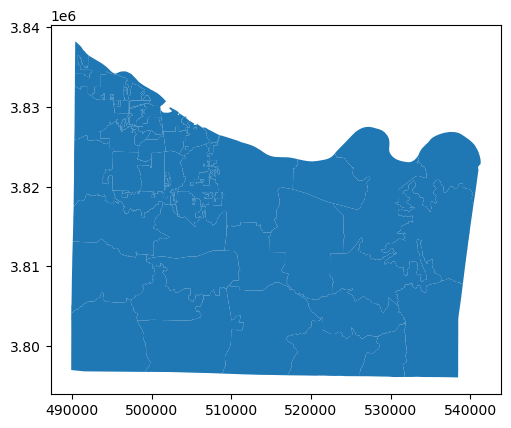

In [139]:
test_final.loc[test_final["County"]=="Morgan"].plot()

In [140]:
#test_final.loc[test_final["County"]=="Morgan"] = gp.clip(test_final.loc[test_final["County"]=="Morgan"],counties[counties["NAME20"]=="Morgan"])

In [141]:
test_final.loc[test_final["COUNTYFP"].isna(),"COUNTYFP"]

Series([], Name: COUNTYFP, dtype: object)

In [142]:
test_final['COUNTYFP'] = test_final['COUNTYFP'].astype(float).astype(int).astype(str).str.zfill(3)
results_24['COUNTYFP'] = results_24['COUNTYFP'].astype(float).astype(int).astype(str).str.zfill(3)

In [143]:
race_cols = ['G24A01NO', 'G24A01YES',
       'G24AJ1OWRI', 'G24AJ1RMCC', 'G24AJ2OWRI', 'G24AJ2RBRY', 'G24AJ3OWRI',
       'G24AJ3RSEL', 'G24AJ4OWRI', 'G24AJ4RMIT', 'G24CFJDGRI', 'G24CFJOWRI',
       'G24CFJRSTE', 'G24CR1OWRI', 'G24CR1RMIN', 'G24CR2OWRI', 'G24CR2RAND',
       'G24CR3OWRI', 'G24CR3RCOL', 'G24CV1OWRI', 'G24CV1REDW', 'G24CV2OWRI',
       'G24CV2RHAN', 'G24CV3OWRI', 'G24CV3RMOO', 'G24PREDHAR', 'G24PREIKEN',
       'G24PREIOLI', 'G24PREISTE', 'G24PREOWRI', 'G24PRERTRU', 'G24PSCOWRI',
       'G24PSCRCAV','GCON01DHOL', 'GCON01OWRI', 'GCON01RMOO', 'GCON02DFIG',
       'GCON02OWRI', 'GCON02RDOB', 'GCON03OWRI', 'GCON03RROG', 'GCON04OWRI',
       'GCON04RADE', 'GCON05OWRI', 'GCON05RSTR', 'GCON06DAND', 'GCON06OWRI',
       'GCON06RPAL', 'GCON07DSEW', 'GCON07OWRI', 'GCON07RLIT']

In [144]:
results_24[race_cols].sum()

G24A01NO       399640
G24A01YES     1159794
G24AJ1OWRI      38088
G24AJ1RMCC    1564832
G24AJ2OWRI      36383
G24AJ2RBRY    1560072
G24AJ3OWRI      35479
G24AJ3RSEL    1557606
G24AJ4OWRI      35034
G24AJ4RMIT    1555235
G24CFJDGRI     756675
G24CFJOWRI       2350
G24CFJRSTE    1458501
G24CR1OWRI      33207
G24CR1RMIN    1547401
G24CR2OWRI      32940
G24CR2RAND    1546549
G24CR3OWRI      32746
G24CR3RCOL    1547520
G24CV1OWRI      33716
G24CV1REDW    1555361
G24CV2OWRI      33644
G24CV2RHAN    1549864
G24CV3OWRI      33096
G24CV3RMOO    1551657
G24PREDHAR     772412
G24PREIKEN      12075
G24PREIOLI       4930
G24PREISTE       4319
G24PREOWRI       8738
G24PRERTRU    1462616
G24PSCOWRI      42061
G24PSCRCAV    1538888
GCON01DHOL      70929
GCON01OWRI        306
GCON01RMOO     258619
GCON02DFIG     158041
GCON02OWRI        219
GCON02RDOB     131414
GCON03OWRI       5160
GCON03RROG     243848
GCON04OWRI       3374
GCON04RADE     274498
GCON05OWRI      12088
GCON05RSTR     250322
GCON06DAND

In [145]:
pdv.county_totals_check(results_24, "Results", test_final[['COUNTYFP']+race_cols], "Shape", race_cols, "COUNTYFP", full_print=False, method='race')

***Countywide Totals Check***

G24A01NO is equal across all counties
G24A01YES is equal across all counties
G24AJ1OWRI is equal across all counties
G24AJ1RMCC is equal across all counties
G24AJ2OWRI is equal across all counties
G24AJ2RBRY is equal across all counties
G24AJ3OWRI is equal across all counties
G24AJ3RSEL is equal across all counties
G24AJ4OWRI is equal across all counties
G24AJ4RMIT is equal across all counties
G24CFJDGRI is equal across all counties
G24CFJOWRI is equal across all counties
G24CFJRSTE is equal across all counties
G24CR1OWRI is equal across all counties
G24CR1RMIN is equal across all counties
G24CR2OWRI is equal across all counties
G24CR2RAND is equal across all counties
G24CR3OWRI is equal across all counties
G24CR3RCOL is equal across all counties
G24CV1OWRI is equal across all counties
G24CV1REDW is equal across all counties
G24CV2OWRI is equal across all counties
G24CV2RHAN is equal across all counties
G24CV3OWRI is equal across all counties
G24CV3RMOO i

In [146]:
test_final[race_cols].sum()

G24A01NO       399640.0
G24A01YES     1159794.0
G24AJ1OWRI      38088.0
G24AJ1RMCC    1564832.0
G24AJ2OWRI      36383.0
G24AJ2RBRY    1560072.0
G24AJ3OWRI      35479.0
G24AJ3RSEL    1557606.0
G24AJ4OWRI      35034.0
G24AJ4RMIT    1555235.0
G24CFJDGRI     756675.0
G24CFJOWRI       2350.0
G24CFJRSTE    1458501.0
G24CR1OWRI      33207.0
G24CR1RMIN    1547401.0
G24CR2OWRI      32940.0
G24CR2RAND    1546549.0
G24CR3OWRI      32746.0
G24CR3RCOL    1547520.0
G24CV1OWRI      33716.0
G24CV1REDW    1555361.0
G24CV2OWRI      33644.0
G24CV2RHAN    1549864.0
G24CV3OWRI      33096.0
G24CV3RMOO    1551657.0
G24PREDHAR     772412.0
G24PREIKEN      12075.0
G24PREIOLI       4930.0
G24PREISTE       4319.0
G24PREOWRI       8738.0
G24PRERTRU    1462616.0
G24PSCOWRI      42061.0
G24PSCRCAV    1538888.0
GCON01DHOL      70929.0
GCON01OWRI        306.0
GCON01RMOO     258619.0
GCON02DFIG     158041.0
GCON02OWRI        219.0
GCON02RDOB     131414.0
GCON03OWRI       5160.0
GCON03RROG     243848.0
GCON04OWRI      

In [147]:
races = [i for i in list(test_final.columns) if i not in ["UNIQUE_ID","COUNTYFP","County","Precinct"]]

In [148]:
def is_split_precinct(district_assignment_list):
    c = Counter([x[0] for x in district_assignment_list])
    greater_than_one = {x:[y[1] for y in district_assignment_list if y[0]==x] for x, count in c.items() if count > 1}
    if len(greater_than_one)==0:
        return 0
    else:
        return greater_than_one
    
def get_level_dist(column_name):
    if column_name[0:3] == "GSL" or column_name[0:3] == "PSL":
        level = "SL"
        dist = column_name[3:6]
    elif column_name[0:3] == "GSU" or column_name[0:3] == "PSU":
        level = "SU"
        dist = column_name[3:5]
    elif column_name[0:3] == "GCO"  or column_name[0:3] == "PCO":
        level = "CON"
        dist = column_name[4:6]
    else:
        print(column_name)
        raise ValueError
    return level,dist

def contains_sldl(dist_list):
    for dist_tuple in dist_list:
        if dist_tuple[0] == "SL":
            return dist_tuple[1]
        
def contains_cong(dist_list):
    for dist_tuple in dist_list:
        if dist_tuple[0] == "CON":
            return dist_tuple[1]
        
def contains_sldu(dist_list):
    for dist_tuple in dist_list:
        if dist_tuple[0] == "SU":
            return dist_tuple[1]

precinct_mapping_dict = {}
split_precincts_list = {}
for index,row in test_final.iterrows():
    precinct_list = []
    for contest in races:
        if(row[contest]!=0) and ("GSL" in contest or "GCO" in contest or "GSU" in contest or "PCO" in contest or "PSU" in contest or "PSL" in contest):
            precinct_info = get_level_dist(contest)
            if precinct_info not in precinct_list:
                precinct_list.append(get_level_dist(contest))
    is_split = is_split_precinct(precinct_list)
    if (is_split):
        split_precincts_list[row["UNIQUE_ID"]]=is_split
    precinct_mapping_dict[row["UNIQUE_ID"]]=precinct_list
    
cong_check_list = {i:contains_cong(precinct_mapping_dict[i]) for i in precinct_mapping_dict.keys()}
sldu_check_list = {i:contains_sldu(precinct_mapping_dict[i]) for i in precinct_mapping_dict.keys()}
sldl_check_list = {i:contains_sldl(precinct_mapping_dict[i]) for i in precinct_mapping_dict.keys()}


In [149]:
def return_splits(split_dict, level):
    for val in split_dict.keys():
        if level in val:
            return split_dict[level]

def create_splits_dict(level):
    level_splits_dict = {i:return_splits(split_precincts_list[i], level) for i in split_precincts_list.keys() if return_splits(split_precincts_list[i], level) != None }
    return level_splits_dict

cong_splits_dict = create_splits_dict('CON')


In [150]:
# 'Clarke-:-MORNING STAR': ['02', '07'],
# # Might be dropped
# 'Clarke-:-WALKER SPRNGS': ['02', '07'],  

In [151]:
test_final[test_final["County"]=="Clarke"][["UNIQUE_ID"]+[i for i in list(test_final.columns) if "GCON02" in i or "GCON07" in i]]

,UNIQUE_ID,GCON02DFIG,GCON02OWRI,GCON02RDOB,GCON07DSEW,GCON07OWRI,GCON07RLIT
286,Clarke-:-ADULT ED_ BLDG_,0.0,0.0,0.0,480.0,0.0,205.0
287,Clarke-:-ANTIOCH FIRE 102_1,0.0,0.0,0.0,169.0,1.0,237.0
288,Clarke-:-BASHI METHODIST 201_2,0.0,0.0,0.0,16.0,0.0,92.0
289,Clarke-:-CHILTON BAPT 151_2,0.0,0.0,0.0,4.0,0.0,98.0
290,Clarke-:-CHOCTAW BLUFF FIRE 12_1,185.0,1.0,104.0,0.0,0.0,0.0
291,Clarke-:-COFFEVILLE HIGH,0.0,0.0,0.0,199.0,0.0,332.0
292,Clarke-:-FIRST ASSEMBLY OF GOD,0.0,0.0,0.0,90.0,0.0,567.0
293,Clarke-:-FULTON FIRE,0.0,0.0,0.0,188.0,0.0,540.0
294,Clarke-:-GAINESTOWN-GOODHOPE 11_1,399.0,0.0,66.0,0.0,0.0,0.0
295,Clarke-:-GOSPORT FIRE,40.0,0.0,3.0,39.0,0.0,13.0


In [152]:
cong_splits_dict

{'Clarke-:-GOSPORT FIRE': ['02', '07'],
 'Clarke-:-JACKSON CITY HALL': ['02', '07'],
 'Clarke-:-JACKSON DOWNTOWN': ['02', '07'],
 'Clarke-:-MORNING STAR': ['02', '07'],
 'Clarke-:-NETTLESBORO': ['02', '07'],
 'Clarke-:-WALKER SPRNGS': ['02', '07'],
 'Jefferson-:-PREC 1010 - HUFFMAN BAPTIST CH': ['06', '07'],
 'Jefferson-:-PREC 1030 - L_M_ SMITH MIDDLE': ['06', '07'],
 'Jefferson-:-PREC 1060 - SUN VALLEY ELEMENT': ['06', '07'],
 'Jefferson-:-PREC 1070 - CRESTWAY BAPTIST C': ['06', '07'],
 'Jefferson-:-PREC 1110 - DON HAWKINS PARK &': ['06', '07'],
 'Jefferson-:-PREC 1125 - CENTER POINT SENIO': ['06', '07'],
 'Jefferson-:-PREC 1130 - MARTHA GASKINS ELE': ['06', '07'],
 'Jefferson-:-PREC 2030 - HIGHLAND PARK GOLF': ['06', '07'],
 'Jefferson-:-PREC 2180 - AVONDALE PUBLIC LI': ['06', '07'],
 'Jefferson-:-PREC 3015 - HOOVER MET SPORTS': ['06', '07'],
 'Jefferson-:-PREC 3040 - PRINCE OF PEACE CA': ['06', '07'],
 'Jefferson-:-PREC 3130 - SHADES CREST BAPTI': ['06', '07'],
 'Jefferson-:-PREC 32

In [153]:
test_final["COUNTYFP"] = test_final["COUNTYFP"].astype(float).astype(int).astype(str).str.zfill(3)

In [154]:
test_final.columns

Index(['UNIQUE_ID', 'COUNTYFP', 'County', 'Precinct', 'G24A01NO', 'G24A01YES',
       'G24AJ1OWRI', 'G24AJ1RMCC', 'G24AJ2OWRI', 'G24AJ2RBRY', 'G24AJ3OWRI',
       'G24AJ3RSEL', 'G24AJ4OWRI', 'G24AJ4RMIT', 'G24CFJDGRI', 'G24CFJOWRI',
       'G24CFJRSTE', 'G24CR1OWRI', 'G24CR1RMIN', 'G24CR2OWRI', 'G24CR2RAND',
       'G24CR3OWRI', 'G24CR3RCOL', 'G24CV1OWRI', 'G24CV1REDW', 'G24CV2OWRI',
       'G24CV2RHAN', 'G24CV3OWRI', 'G24CV3RMOO', 'G24PREDHAR', 'G24PREIKEN',
       'G24PREIOLI', 'G24PREISTE', 'G24PREOWRI', 'G24PRERTRU', 'G24PSCOWRI',
       'G24PSCRCAV', 'GCON01DHOL', 'GCON01OWRI', 'GCON01RMOO', 'GCON02DFIG',
       'GCON02OWRI', 'GCON02RDOB', 'GCON03OWRI', 'GCON03RROG', 'GCON04OWRI',
       'GCON04RADE', 'GCON05OWRI', 'GCON05RSTR', 'GCON06DAND', 'GCON06OWRI',
       'GCON06RPAL', 'GCON07DSEW', 'GCON07OWRI', 'GCON07RLIT', 'geometry'],
      dtype='object')

In [155]:
import maup

In [156]:
test_final.columns

Index(['UNIQUE_ID', 'COUNTYFP', 'County', 'Precinct', 'G24A01NO', 'G24A01YES',
       'G24AJ1OWRI', 'G24AJ1RMCC', 'G24AJ2OWRI', 'G24AJ2RBRY', 'G24AJ3OWRI',
       'G24AJ3RSEL', 'G24AJ4OWRI', 'G24AJ4RMIT', 'G24CFJDGRI', 'G24CFJOWRI',
       'G24CFJRSTE', 'G24CR1OWRI', 'G24CR1RMIN', 'G24CR2OWRI', 'G24CR2RAND',
       'G24CR3OWRI', 'G24CR3RCOL', 'G24CV1OWRI', 'G24CV1REDW', 'G24CV2OWRI',
       'G24CV2RHAN', 'G24CV3OWRI', 'G24CV3RMOO', 'G24PREDHAR', 'G24PREIKEN',
       'G24PREIOLI', 'G24PREISTE', 'G24PREOWRI', 'G24PRERTRU', 'G24PSCOWRI',
       'G24PSCRCAV', 'GCON01DHOL', 'GCON01OWRI', 'GCON01RMOO', 'GCON02DFIG',
       'GCON02OWRI', 'GCON02RDOB', 'GCON03OWRI', 'GCON03RROG', 'GCON04OWRI',
       'GCON04RADE', 'GCON05OWRI', 'GCON05RSTR', 'GCON06DAND', 'GCON06OWRI',
       'GCON06RPAL', 'GCON07DSEW', 'GCON07OWRI', 'GCON07RLIT', 'geometry'],
      dtype='object')

In [157]:
## Clean up N/A District Assignments


def clean_na_dist_assignments(elections_gdf, district_gdf, unique_ID_col, elections_gdf_dist_ID, district_gdf_ID, ):
    
    if elections_gdf[elections_gdf[elections_gdf_dist_ID].isna()].shape[0]==0:
        return elections_gdf
    
    else:
        print("Fixing ",elections_gdf[elections_gdf[elections_gdf_dist_ID].isna()].shape[0], "precincts")
    
    original_crs = elections_gdf.crs
    elections_gdf = elections_gdf.to_crs(3857)
    
    district_gdf = district_gdf.to_crs(3857)
    
    dist_clean = gp.overlay(elections_gdf[elections_gdf[elections_gdf_dist_ID].isna()], district_gdf, how = "intersection")

    dist_clean['area'] = dist_clean.area

    na_assignment_dict = {}

    for val in dist_clean[unique_ID_col].unique():

        assignment = dist_clean.loc[dist_clean[unique_ID_col] == val].nlargest(1, 'area')[district_gdf_ID].values[0]
        na_assignment_dict[val] = assignment

    elections_gdf[elections_gdf_dist_ID] = elections_gdf[unique_ID_col].map(na_assignment_dict).fillna(elections_gdf[elections_gdf_dist_ID])    

    elections_gdf = elections_gdf.to_crs(original_crs)
    
    return elections_gdf

In [158]:
CONG_PATH = "/Users/peterhorton/Documents/RDH/raw_data/cong/national_cong119_boundary/national_cong119_boundary/national_cong119_boundary.shp"

# Load in CONG and SLDU shapefiles
al_cong_districts = gp.read_file(CONG_PATH)

al_cong_districts = al_cong_districts.to_crs(test_final.crs)

al_cong_districts = al_cong_districts[al_cong_districts["STATE"]=="AL"]

test_final["CONG_DIST"] = test_final["UNIQUE_ID"].map(cong_check_list)

# # Clean na district assignments
test_final = clean_na_dist_assignments(test_final, al_cong_districts, "UNIQUE_ID", "CONG_DIST", "DISTRICT")

Fixing  1 precincts


In [159]:
cong_columns = [i for i in list(test_final.columns) if "GCON" in i]

In [160]:
al_cong_districts.rename(columns = {"CONG_DIST":"DISTRICT"}, inplace = True)
test_final_unsplit = test_final.copy(deep = True)
test_final, cong_diff = pdv.district_splits_comb("CONG", list(cong_splits_dict.keys()), test_final, al_cong_districts, "UNIQUE_ID", "DISTRICT", cong_columns, "CONG_DIST")


In [161]:
cong_diff

,GCON06DAND,GCON06RPAL,Tot_Votes
UNIQUE_ID,,,
Jefferson-:-PREC 1030 - L_M_ SMITH MIDDLE,2.0,0.0,2.0
Jefferson-:-PREC 1070 - CRESTWAY BAPTIST C,2.0,0.0,2.0
Jefferson-:-PREC 1110 - DON HAWKINS PARK &,31.0,6.0,37.0
Jefferson-:-PREC 1130 - MARTHA GASKINS ELE,2.0,1.0,3.0
Jefferson-:-PREC 3290 - MULGA TOWN HALL,0.0,3.0,3.0
Jefferson-:-PREC 3330 - FIRST BAPT CHURCH,43.0,7.0,50.0


<!-- # Remaining files to check
~Butler~, ~Covington~, ~Perry~, ~Jackson~, ~Tallapoosa~
~Calhoun~, ~Cherokee (no map)~ ~Cleburne (one boundary matches VTD)~ ~Geneva~, ~Hale~, ~Lamar~, ~Randolph~ -->

<!-- CLARKE (SWAP), DALLAS (SWAP), WASHINGTON (SWAP) -->

Checking 7 Districts for differences of greater than 0.1 km^2

1) For 01 difference in area is 121.97983252760791
2) For 04 difference in area is 0.42851607363512095
3) For 05 difference in area is 0.7230068067833575
4) For 06 difference in area is 0.10191898891800073
5) For 07 difference in area is 0.25923769708616023

Scroll down to see plots of any differences

Of the 7 Districts:

0 Districts w/ a difference of 0 km^2
2 Districts w/ a difference between 0 and .1 km^2
3 Districts w/ a difference between .1 and .5 km^2
1 Districts w/ a difference between .5 and 1 km^2
0 Districts w/ a difference between 1 and 2 km^2
0 Districts w/ a difference between 2 and 5 km^2
1 Districts w/ a difference greater than 5 km^2
Checking 67 County for differences of greater than 0.1 km^2

1) For 003 difference in area is 121.93874020547524
2) For 103 difference in area is 0.4589563403269415

Scroll down to see plots of any differences

Of the 67 County:

0 County w/ a difference of 0 km^2
65 County w/

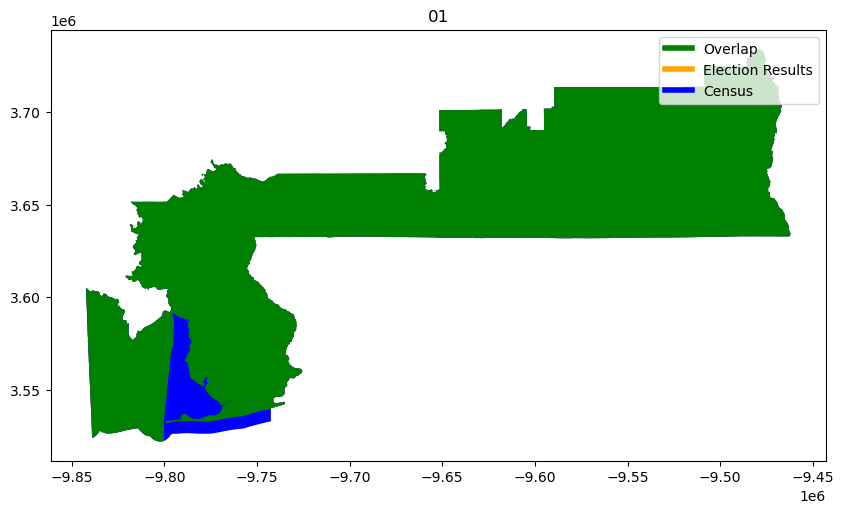

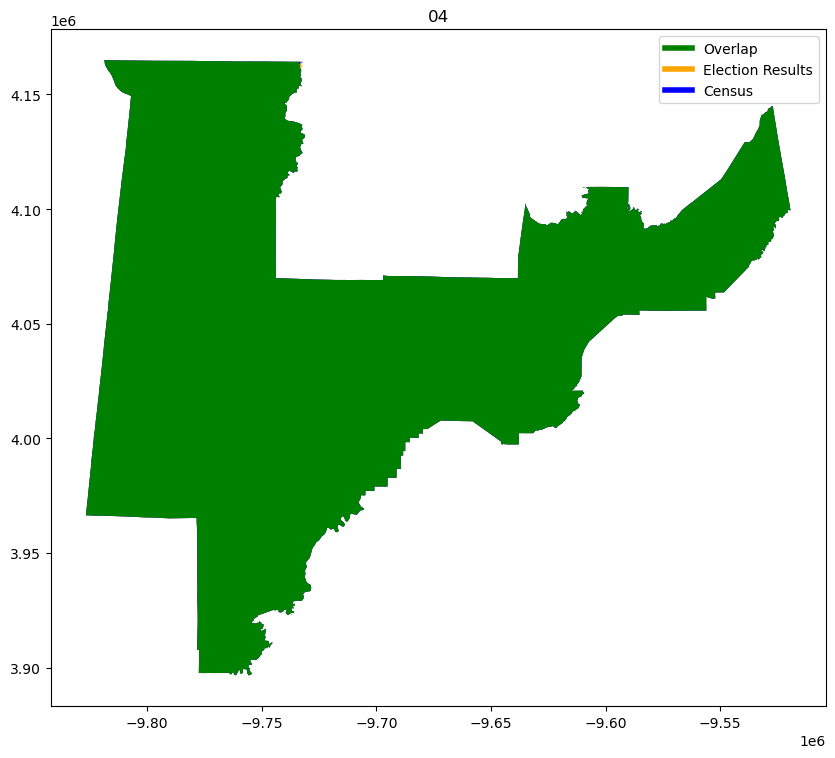

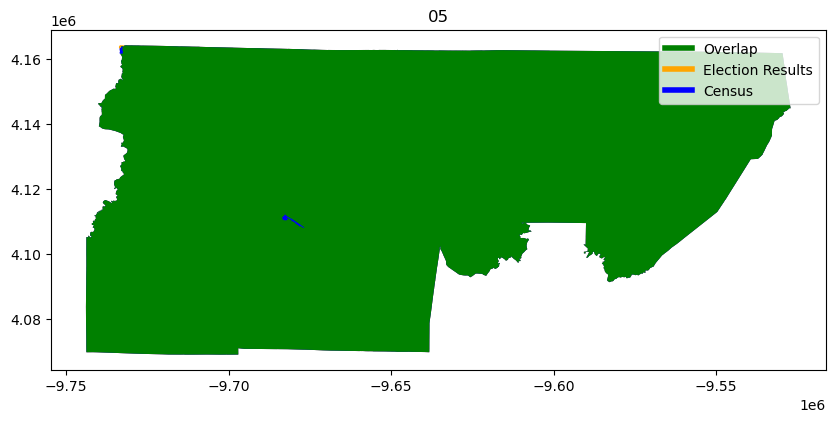

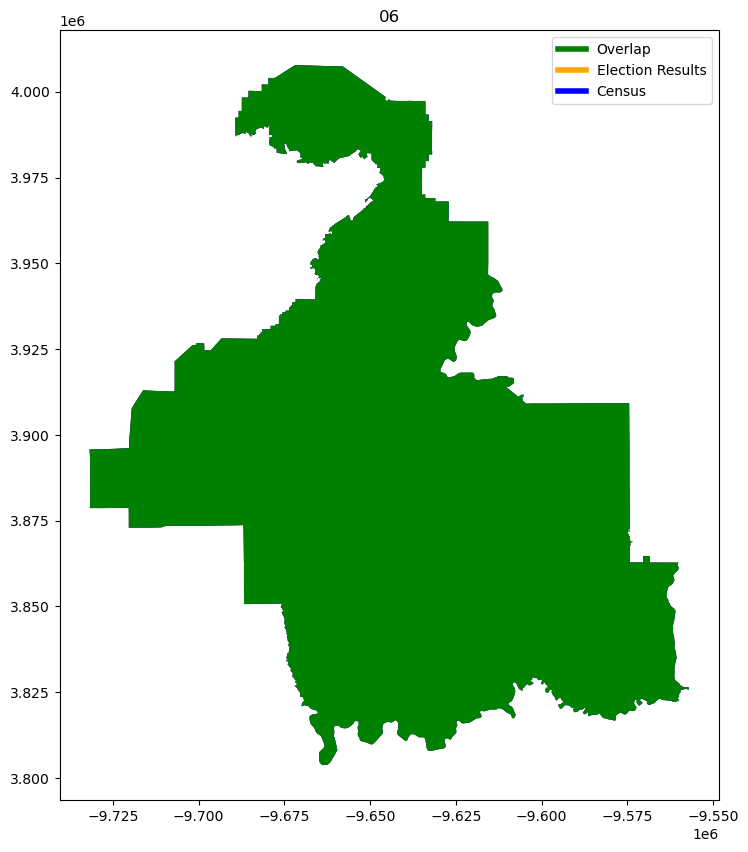

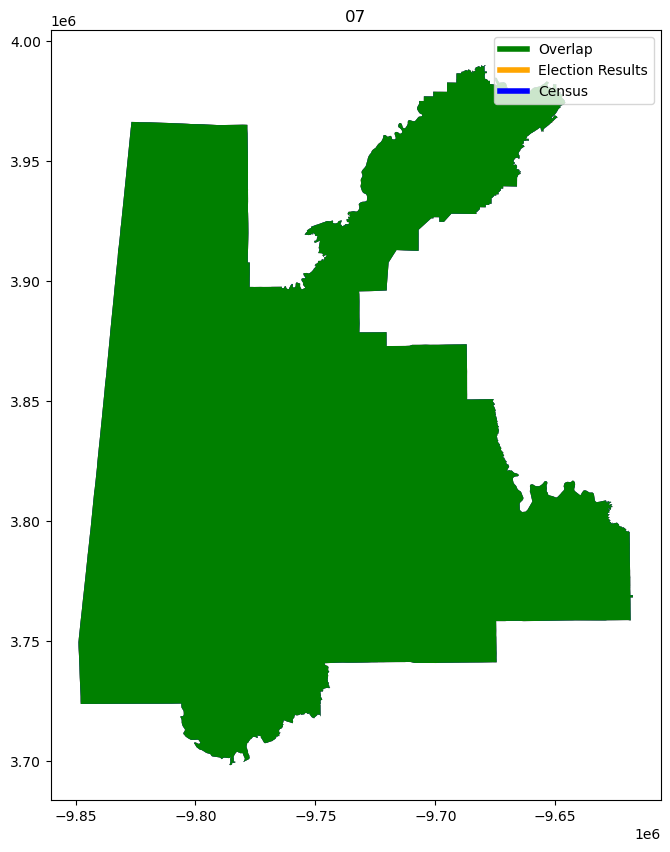

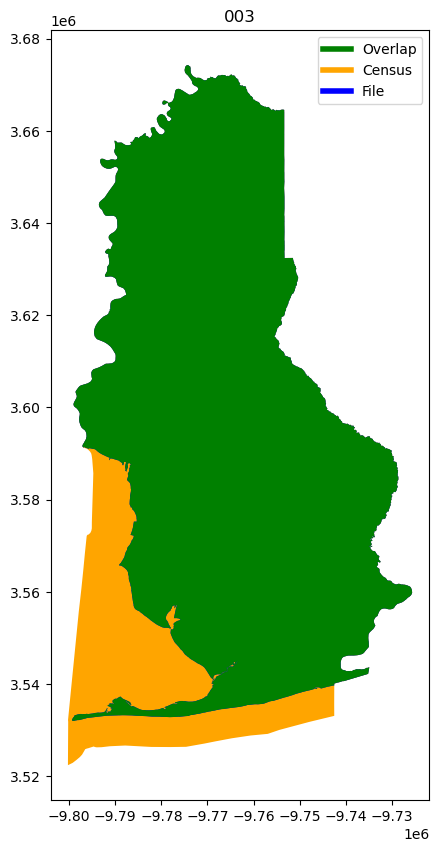

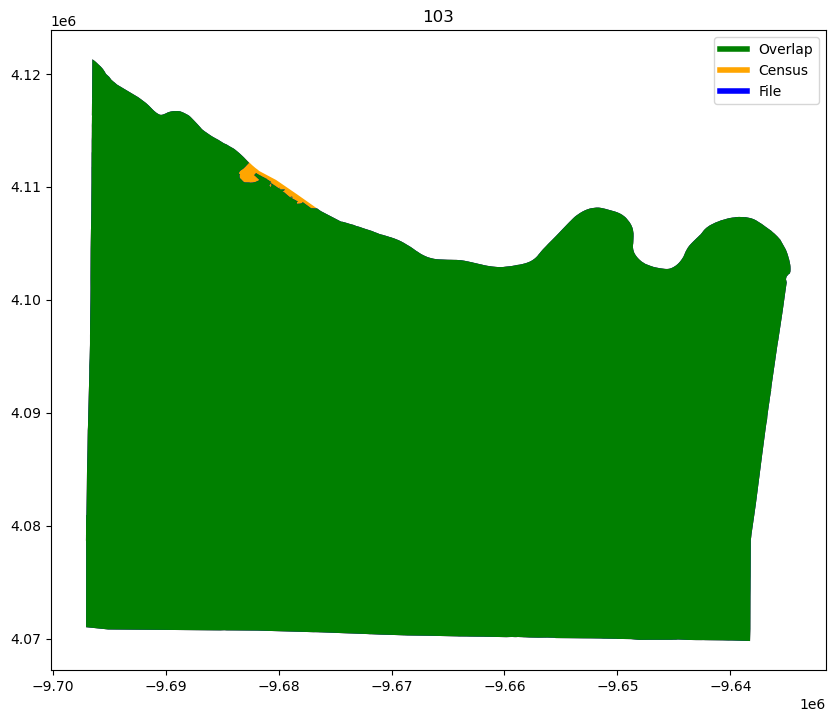

In [162]:

test_final["CONG_DIST"] = test_final["CONG_DIST"].astype(str).str.zfill(2)

al_cong_districts.rename(columns = {"DISTRICT":"CONG_DIST"}, inplace = True)

filtered_cong_results = test_final[~test_final["CONG_DIST"].isna()].dissolve("CONG_DIST")
filtered_cong_results.reset_index(inplace = True, drop = False)

al_cong_districts["CONG_DIST"] = al_cong_districts["CONG_DIST"].astype(str).str.zfill(2)



# Check implied SLDU districts based off of assignments against the actual ones
pdv.compare_geometries(filtered_cong_results, al_cong_districts ,"Election Results", "Census", "CONG_DIST","Districts",area_threshold=.1)




test_final.rename(columns = {"COUNTY_FIP":"COUNTYFP"}, inplace = True)

## Check Implied Parish Assignments

COUNTY_PATH = "/Users/peterhorton/Documents/RDH/raw_data/census/2020_TIGER_CNTY/al_cnty_2020_bound/al_cnty_2020_bound.shp"

al_counties = gp.read_file(COUNTY_PATH)
al_counties.rename(columns = {"COUNTYFP20":"COUNTYFP"}, inplace = True)
grouped_counties = test_final.dissolve("COUNTYFP")
grouped_counties.reset_index(inplace = True, drop = False)

pdv.compare_geometries(al_counties, grouped_counties, "Census", "File", "COUNTYFP", "County")






In [163]:
cong_cols = ['GCON01DHOL', 'GCON01OWRI', 'GCON01RMOO', 'GCON02DFIG',
       'GCON02OWRI', 'GCON02RDOB', 'GCON03OWRI', 'GCON03RROG', 'GCON04OWRI',
       'GCON04RADE', 'GCON05OWRI', 'GCON05RSTR', 'GCON06DAND', 'GCON06OWRI',
       'GCON06RPAL', 'GCON07DSEW', 'GCON07OWRI', 'GCON07RLIT']

In [164]:
## Final File Cleaning and Export File

if not os.path.exists("./al_2024_gen_prec"):
    os.mkdir("./al_2024_gen_prec/")
    
if not os.path.exists("./al_2024_gen_prec/al_2024_gen_cong_prec"):
    os.mkdir("./al_2024_gen_prec/al_2024_gen_cong_prec")
if not os.path.exists("./al_2024_gen_prec/al_2024_gen_all_prec"):
    os.mkdir("./al_2024_gen_prec/al_2024_gen_all_prec")
    
        
test_final = gp.GeoDataFrame(test_final[['UNIQUE_ID',"COUNTYFP",
 'County',
 'Precinct',
'CONG_DIST']+cong_cols+["geometry"]])

test_final_unsplit = gp.GeoDataFrame(test_final_unsplit[['UNIQUE_ID',"COUNTYFP",
 'County',
 'Precinct']+race_cols+["geometry"]])




test_final.to_file("./al_2024_gen_prec/al_2024_gen_cong_prec/al_2024_gen_cong_prec.shp")
test_final_unsplit.to_file("./al_2024_gen_prec/al_2024_gen_all_prec/al_2024_gen_all_prec.shp")


# test_final["COUNTYFP"] = test_final["COUNTYFP"].astype(int).astype(str).str.zfill(3)

# results = test_final.drop(["geometry"], axis = 1)
# results.to_csv("./al_2024_gen_prec/al_2024_gen_prec.csv", index = False)




In [165]:
for file in os.listdir('./al_2024_gen_prec/'):
    print(file)


os.remove('./al_2024_gen_prec/.DS_Store')

.DS_Store
al_2024_gen_cong_prec
README.txt
al_2024_gen_all_prec


In [166]:
for file in os.listdir('./al_2024_gen_prec/'):
    print(file)

al_2024_gen_cong_prec
README.txt
al_2024_gen_all_prec


In [168]:
import shutil

shutil.make_archive('./al_2024_gen_prec', 'zip', './al_2024_gen_prec')

'/Users/peterhorton/Documents/RDH/pber_local/AL_2024/general/al_2024_gen_prec.zip'